# Настройка инструментов

<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Инициализация среды</p></div>


*Импортируем библиотеки для работы с данными.*


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

# Обёртки для диаграмм
from researchers_tools import (
    custom_pie_chart,
)

from phik import phik_matrix

*Загрузим конфигурации research обалсти.*

In [2]:
from settings import CONFIGS_DIR

import json

with open(CONFIGS_DIR / 'baseline_v1.json', encoding="utf-8") as f:
    config = json.load(f)

Инструменты пайплайна

In [3]:
from research.preprocessing.surface_processing import TitanicPreprocessor
from research.schemas import TitanicSchemaNormalizer

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 242px;font-weight: 600;">Настройка визуализации</p></div>


*Настройка визуализации.*


In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

from core.researchers_tools.settings import (
    GRAPH_STYLES,
    PROP_CYCLE,
)

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PROP_CYCLE)
plt.rcParams.update(GRAPH_STYLES)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 319px;font-weight: 600;">Загрузка и настройка ресурсов</p></div>


**Наименование:** titanic.<br>**Путь к файлу:** datasets/raw/train.csv <br><br>


_Считаем и переименуем._

In [5]:
from settings import RAW_DATASET_DIR

titanic = pd.read_csv(
    RAW_DATASET_DIR / config["raw_datasets"]["train"]['titanic']
)

normalizer = TitanicSchemaNormalizer()
titanic = normalizer.fit_transform(titanic)

titanic.head(0)

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,embarked,survived


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Общая информация


**Название таблицы**


In [6]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   passenger_id               891 non-null    int64  
 1   ticket_id                  891 non-null    str    
 2   name                       891 non-null    str    
 3   sex                        891 non-null    str    
 4   age                        714 non-null    float64
 5   same_importance_relatives  891 non-null    int64  
 6   high_importance_relatives  891 non-null    int64  
 7   category_significance      891 non-null    int64  
 8   fare                       891 non-null    float64
 9   cabin                      204 non-null    str    
 10  embarked                   889 non-null    str    
 11  survived                   891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


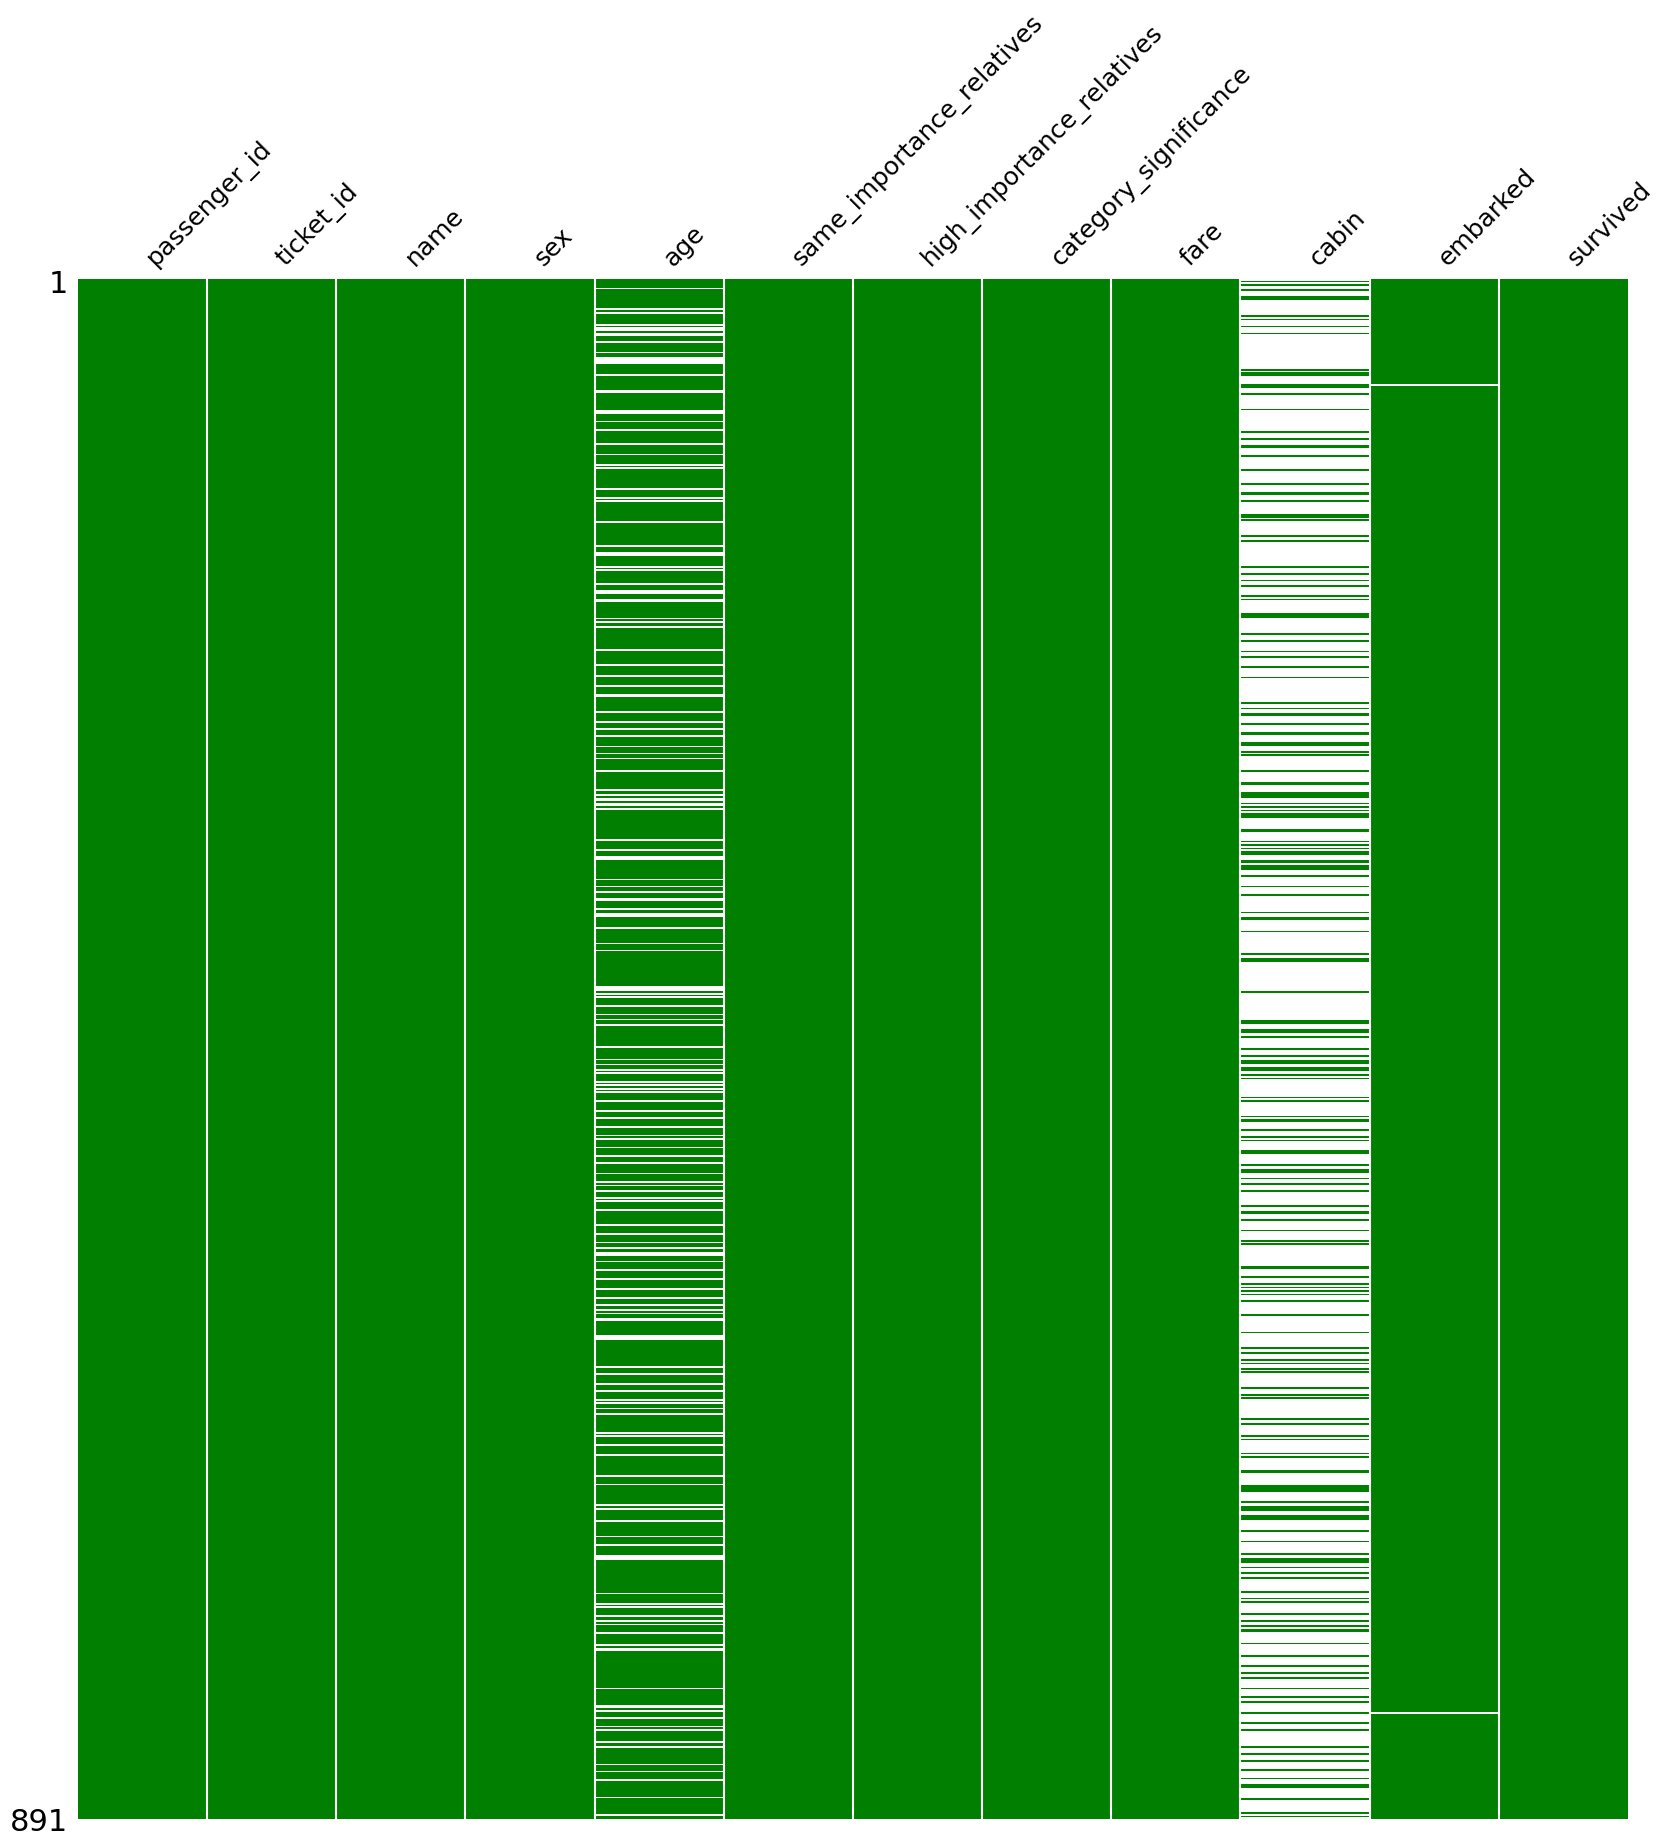

In [7]:
msno.matrix(
    titanic,
    color=(0, 0.5, 0),
    fontsize=18,
    sparkline=False,
    figsize=(20, 20)
);

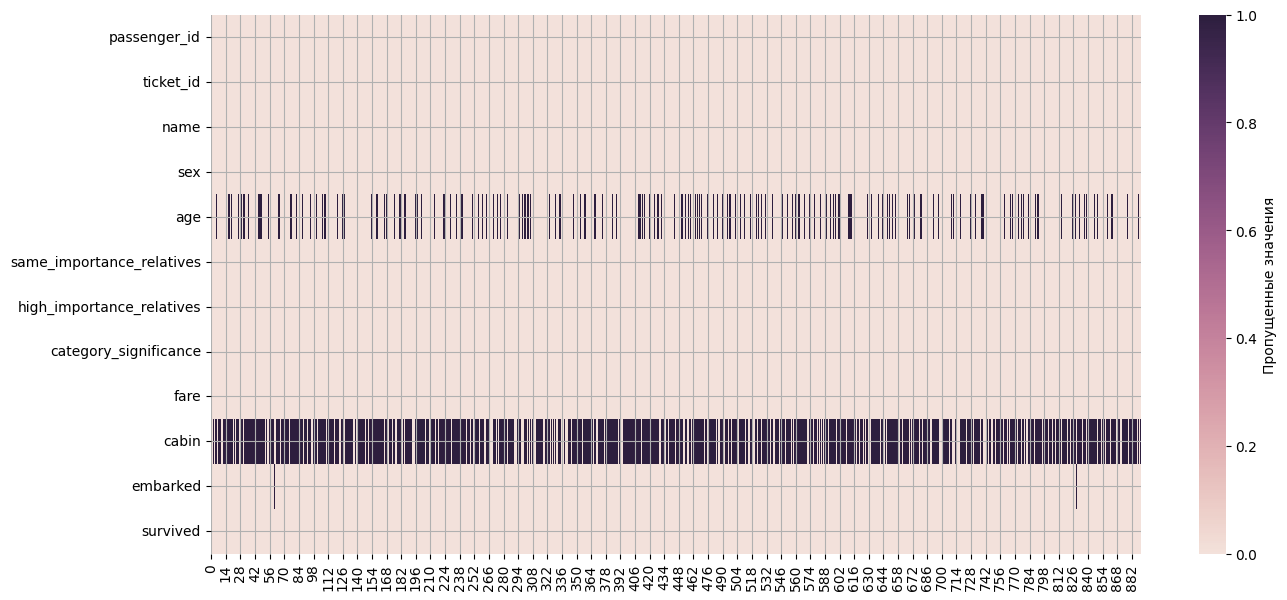

In [8]:
plt.figure(figsize=(15, 7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(
    titanic.isna().transpose(),
    cmap=cmap,
    cbar_kws={'label': 'Пропущенные значения'}
);

*Посмотрим есть ли зависимость между пропусками.*


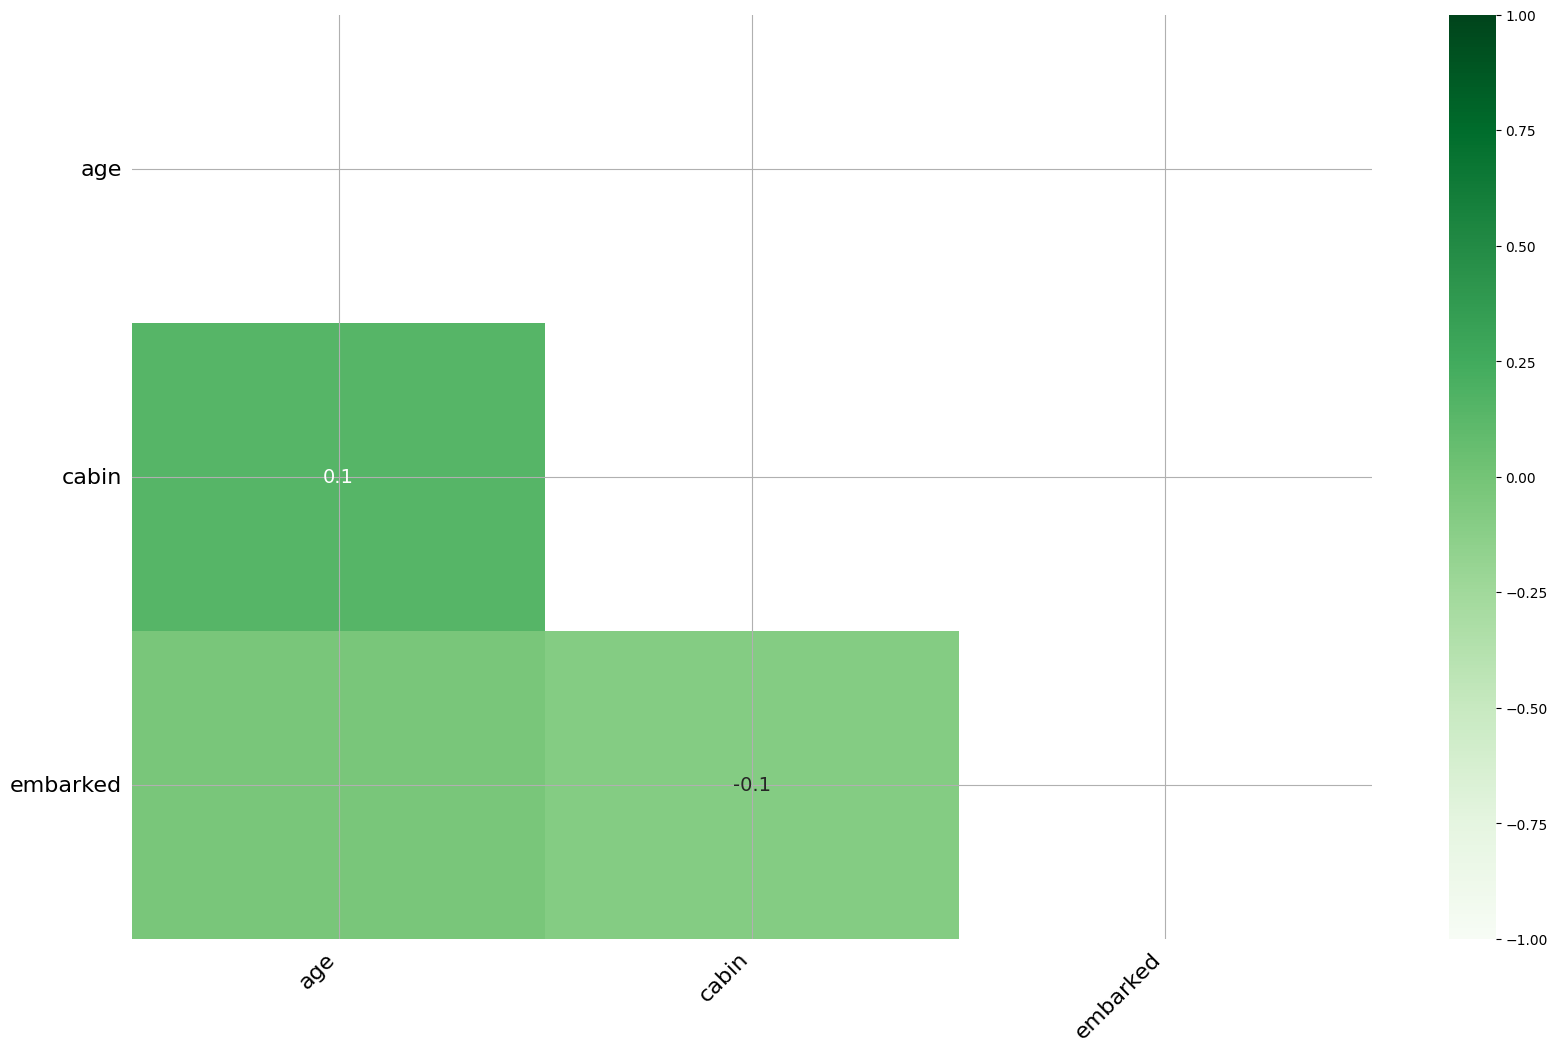

In [9]:
msno.heatmap(titanic, cmap='Greens');

# Предобработка данных


In [10]:
preprocessor = TitanicPreprocessor()

titanic = preprocessor.fit_transform(titanic)

# Промежуточный вывод


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 300px;font-weight: 600;">Обобщение выводов предобработки</p></div>


<ul>
<li>

**@titanic `ticket_id`.**

Данные в этом признаке содержали аномалию, связанную с случайными символами "." и "/", но проведя исследование аномалии мы пришли к выводу, что проводить коррекцию данных не имеет смысла.

Некоторые люди с одной фамилией или иными признаками родства имели разные номера билетов, например билеты "2695", "2690".

Можно попробовать разделить признак ticket_id на id и строчную преписку из букв;
</li>

<li>

**@titanic `name`.**

Обозначение осознанности, которое несёт смысл вставлено в имя (Master, Mr, Miss, Mrs), когда лучше его вынести в отдельный признак на равне с признаком age. Создать признак age_level.

 поле name заложены имена и фамилии. Из-за имени дубликатов практически нет, что ломает нам всю картину для более глубокого анализа, следовательно нужно попробовать создать признак  family.
</li>

<li>

**@titanic `sex`.**

По какой-то причине на титанике было 577 человек мужского пола, в то время как женского пола всего 313.

Также пока не понятно что делать с пропусками. Нужно смотреть корреляции.

</li>

<li>

**@titanic `age`.**

Нужно создать новые признаки, объединив признак age с другими.

Подозрения на аномалии:
- Очень большое количество пропусков в признаке age связано с пассажирами 3ей категории;
- Большое количество детей меньше года;
- 77% пропущенных значений - люди из 3ей категории;
- 5 человек старше 70.
<br>

</li>

<li>

**@titanic `fare`.**

Люди, которые заплатили сверх цену платили за несколько кабин. Одна и та же цена  записывается каждому члену семьи.

Также было обнаружено, что есть определённые категории цен, но при этом сами по себе они сильно разнятся - нужно посмотреть под одну категорию попадают только члены одной семьи или в целом многие заплатили одинаково. Возможно сегментация может что-то прояснить в данных, чего мы не видели. (очень часто все дубликаты имеют одну категорию значимости, а при увеличении стоимости билета увеличиваются также и количества родственников, которых оформили на один билет)

Есть пассажиры, которые заплатили 0. Причина также не ясна.

Есть несколько закономерностей, которые связывают категорию людей не оплативших проезд:

1. Абсолютно все эти люди мужчины;
2. Каждый мужчина не оплативший проезд не имел никаких родственников;
3. Все сели в одном и тот же порту;
4. Все ехали либо по одиночке либо вместе с другими такими же
<br>
Мы могли бы счесть этих пассажиров важными, если бы в датасете не было ещё 500 человек абсолютно без родственников. То есть первые 3 признака буквально не говорят ни о чём, а 4ый как будто просто следствие из остальных.

В общем, в данных просто не хватает признаков, чтобы описать эту отдельную категорию людей, которые абсолютно не заплатили за проезд. Я склоняюсь к тому, чтобы заполнить эти нулевые значения. В любом случае их слишком мало, чтобы очень сильно углублятся в исследование - нужно иметь в виду.

</li>

<li>

**@titanic `cabin`.**

Удалить признак cabin, превратив его в набор признаков:
   - палуба;
   - признак неопределённости: 1 → конкретная каюта известна, 2+ -> пассажир связан с несколькими каютами;
   - каюта определенна однозначно;
   - члены семьи находятся далеко друг от друга на этаже;
   - один из членов семьи находится в конце корридора.
   - создать признак в одной кабине было больше одного человека (тут есть вероятность, что они повторяются даже без родства)
</li>
</ul>

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 299px;font-weight: 600;">Неизученные признаки (уязвимости)</p></div>


* @titanic `sex`;
* @titanic `age`;
* @titanic `category_significance`;
* @titanic `fare`;
* @titanic `cabin`;
* @titanic `survived`;
* @titanic `embarked`.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Инженерия признаков (FE)


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Единичная инженерия</p></div>


In [11]:
print('Размер до трансформации', titanic.shape)

# --------------------------------------------------------------
# @titanic ticket_id
# --------------------------------------------------------------
# Разделить признак ticket_id на id и строчную преписку из букв
ticket_parts = titanic['ticket_id'].str.split(' ')

titanic['ticket_number'] = (
    ticket_parts
    .str[-1]
    .str.extract(r'(\d+)', expand=False)
)
titanic['ticket_prefix'] = (
    ticket_parts
    .str[:-1]
    .str.join(' ')
    .str.replace(r'[./\s]', '', regex=True)
    .str.replace(r'[0-9]', '', regex=True)
    .str.lower()
    .replace('', 'NO_PREFIX')
)

# До корреляционного анализа заполним людей, с ticket_id = LINE
# вручную, после чего уже будем решать удалять пассажиров или
# удалять новые признаки при слабой корреляции
titanic.loc[
    titanic['passenger_id'].isin([597, 302, 271, 179]),
    'ticket_prefix'
] = 'LINE'

titanic.loc[
    titanic['passenger_id'].isin([597, 302, 271, 179]),
    'ticket_number'
] = 1

# ---------------------------------------------------------------
# @titanic age
# ---------------------------------------------------------------
titanic['social_role'] = (
    titanic['name']
    .str.extract(r'\b(Master|Mr|Miss|Mrs)\.', expand=False)
    .map({
        'Master': 'child',
        'Miss': 'child',
        'Mrs': 'adult',
        'Mr': 'adult'
    })
    .fillna('other')
)

titanic['social_role_and_sex'] = (
    titanic['name']
    .str.extract(r'\b(Master|Mr|Miss|Mrs)\.', expand=False)
    .map({
        'Master': 'young_man',
        'Miss': 'young_woman',
        'Mrs': 'adult_woman',
        'Mr': 'adult_man'
    })
    .fillna('other')
)

titanic['surname'] = (
    titanic['name']
    .str.split(',')
    .str[0]
)

titanic['name_custom'] = (
    titanic['name']
    .str.split(',')
    .str[-1]
    .str.replace(r'(Master\.|Miss\.|Mrs\.|Mr\.)', '', regex=True)
    .str.strip()
)

# ---------------------------------------------------------------
# @titanic age
# ---------------------------------------------------------------
titanic['age_group'] = pd.cut(
    titanic['age'],
    bins=[0, 5, 12, 18, 30, 50, 65, 100],
    labels=[
        'infant',
        'child',
        'teen',
        'young_adult',
        'adult',
        'mature',
        'senior'
    ]
)

# ---------------------------------------------------------------
# @titanic same_importance_relatives & high_importance_relatives
# ---------------------------------------------------------------
titanic['is_alone'] = (
        (titanic['same_importance_relatives'] == 0) &
        (titanic['high_importance_relatives'] == 0)
).astype(int)

# ---------------------------------------------------------------
# @titanic cabin
# ---------------------------------------------------------------
# Сделать признак палуба:
titanic['deck'] = (
    titanic['cabin']
    .str.split()
    .apply(
        lambda x: '_'.join(sorted({cabin[0] for cabin in x}))
        if isinstance(x, list) else np.nan
    )
)
titanic['multiple_decks'] = (
    titanic['deck']
    .str.contains('_', na=False)
    .astype('uint8')
)

titanic['cabin_count'] = (
    titanic['cabin']
    .str.split()
    .str.len()
    .fillna(0)
    .astype('uint8')
)

# признак неопределённости:
# - 0 → пропуски в каютах;
# - 1 → конкретная каюта известна (определена однозначно);
# - 2+ → пассажир связан с несколькими каютами (не определена).
titanic['cabin_assignment'] = (
    titanic['cabin']
    .str.split()
    .str.len()
    .clip(upper=2)
    .fillna(0)
    .astype('uint8')
)

print('Размер после трансформации', titanic.shape)

titanic[[
    'ticket_number', 'ticket_prefix', 'social_role',
    'name_custom', 'age_group', 'multiple_decks',
    'cabin_assignment', 'deck', 'surname'
]].sample(3)

Размер до трансформации (887, 12)
Размер после трансформации (887, 24)


,ticket_number,ticket_prefix,social_role,name_custom,age_group,multiple_decks,cabin_assignment,deck,surname
34,17604,pc,adult,Edgar Joseph,young_adult,0,0,NaN,Meyer
156,35851,NO_PREFIX,child,"Katherine ""Katie""",teen,0,0,NaN,Gilnagh
636,3101292,stono,adult,Antti Gustaf,adult,0,0,NaN,Leinonen


**Вывод:**

*Некоторые интересные признаки, которые в теории могут дать информацию теряют свою ценность из-за большого количетсва пропусков в `cabin`, из-за чего мы просто не можем их создать:*
- *члены семьи находятся далеко друг от друга на этаже;*
- *один из членов семьи находится в конце корридора;*
- *создать признак в одной кабине было больше одного человека (тут есть вероятность, что они повторяются даже без родства);*

*То есть признак должен быть не только связан с целевой переменной, он ещё должен быть стабильно вычислимым на новых данных.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Реестр гипотез

<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">01</h3></div>


**Действия:** построить стандартные матрицы корреляций для таблицы Titanic: общую и разделённые по целевому признаку

**Мотивация:** не вижу как данные играют вместе, а также не вижу что отличает жизнь выжившего человека от жизни погибшего в рамках тех признаков, которые собирались.

**На какие вопросы я отвечаю:** Что такое титаник? Какие связи есть в системе? Как устроен мир выжившего и погибшего?

**Возможные инженерные исходы: (связь с бизнес целью)**

* найти формулу формирования целевого признака -> построить модель
* определить признаки для углубленного анализа -> улучшить качество признаков
* выявить признаки, дублирующие друг друга -> улучшить качество признаков
* посмотреть на скачки зависимостей из-за разных целевых -> разделить данные на группы -> улучшить качество признаков

**Стоимость оправдана?**

Да

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">02</h3></div>


**На какие вопросы я отвечаю:** почему deck связан с sex и age

**Действия:** попробовать изучить признаки соединив их разными инструментами.

**Мотивация:** в матрице корреляций обнаружена значимая зависимость, происхождение которой непонятно.

**Возможные инженерные исходы: (связь с бизнес целью)**

* заполнение пропусков deck;
* заполнение пропусков age;
* создание новых признаков;
* отказ от использования deck.

**Стоимость оправдана?**

Да

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">03</h3></div>


**Действия:** построить матрицу корреляций для таблицы Ticket_group

**Мотивация:** существующая таблица Titanic смещает распределения `fare`, `cabin`, `embmarket`, `cabin_counts`, `category_significance` из-за присутствия дубликатов. Хочется углубленно изучить смещённые признаки.

**На какие вопросы я отвечаю:** какие связи после группировки по билетам?

**Возможные инженерные исходы: (связь с бизнес целью)**

* улучшить качество признаков;

**Стоимость оправдана?**

Да

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">04</h3></div>


**На какие вопросы я отвечаю:** что происходит с fare?

**Действия:** сгруппировать по всем наиболее зависимым признакам

**Мотивация:** в разделе предобработке обнаружилось неровное распределение и некоторое количество значений похожих на аномалии. (максимальные значения) Признак стоит в неизученных по выводу. Также не понятно как цена могла быть 0.

**Возможные инженерные исходы: (связь с бизнес целью)**

* заполнение Deck;
* стандартизация Fare;
* отказ от дальнейшего исследования Fare.

**Стоимость оправдана?**

Да, если делать только то, что подскажет можно ли лучше заполнить Deck или Age.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">05</h3></div>


**Действия:** проанализировать разными методами таблицу, в которой один билет пренадлежал разным семьям

**Мотивация:** не могу точно объяснить закономерность, которая уже ни раз попадается на глаза. По логике могут быть братья и сёстры с разной фамилией или же друзья.

**На какие вопросы я отвечаю:** почему встречались несколько семей на один билет?

**Возможные инженерные исходы: (связь с бизнес целью)**

* создание групповых признаков;
* отказ от использования ticket_id как признака группы;
* корректировка family_group;
* отказ от гипотезы.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 36px;font-weight: 600;">06</h3></div>


**На какие вопросы я отвечаю:** как были устроены ticket_prefix?

**Действия:** исследовать структуру ticket_prefix и его связи с другими признаками.

**Мотивация:** в ходе Feature Engineering билет был разделён на числовую и буквенную части. Посмотреть иммет ли это смысл.

**Возможные инженерные исходы: (связь с бизнес целью)**

* создать новый информативный признак;
* объединить редкие категории;
* удалить ticket_prefix как бесполезный признак;
* отказаться от дальнейшего исследования ticket_prefix.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Общие исследования (EDA)


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 436px;font-weight: 600;">Подготовка и настройка инструментов</h3></div>


In [12]:
titanic_true = titanic.query("survived == 1")
titanic_false = titanic.query("survived == 0")

interval_cols = [
    'age', 'same_importance_relatives',
    'fare', 'high_importance_relatives'
]

drop_cols = [
    'passenger_id', 'ticket_id', 'ticket_number',
    'name', 'name_custom', 'surname', 'cabin'
]

phik_corr_matrix_1 = phik_matrix(
    titanic.drop(columns=drop_cols),
    interval_cols=interval_cols
)

# Хитмап для "True target"
phik_corr_matrix_2 = phik_matrix(
    titanic_true.drop(columns=drop_cols + ['survived']),
    interval_cols=interval_cols
)

# Хитмап для "False target"
phik_corr_matrix_3 = phik_matrix(
    titanic_false.drop(columns=drop_cols + ['survived']),
    interval_cols=interval_cols
)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div style="text-align: center;">

<h3>Heatmap <code>Titanic</code> общий</h3>

</div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 445px;font-weight: 600;">Что такое титаник? <br> Какие связи есть в системе?</h3></div>


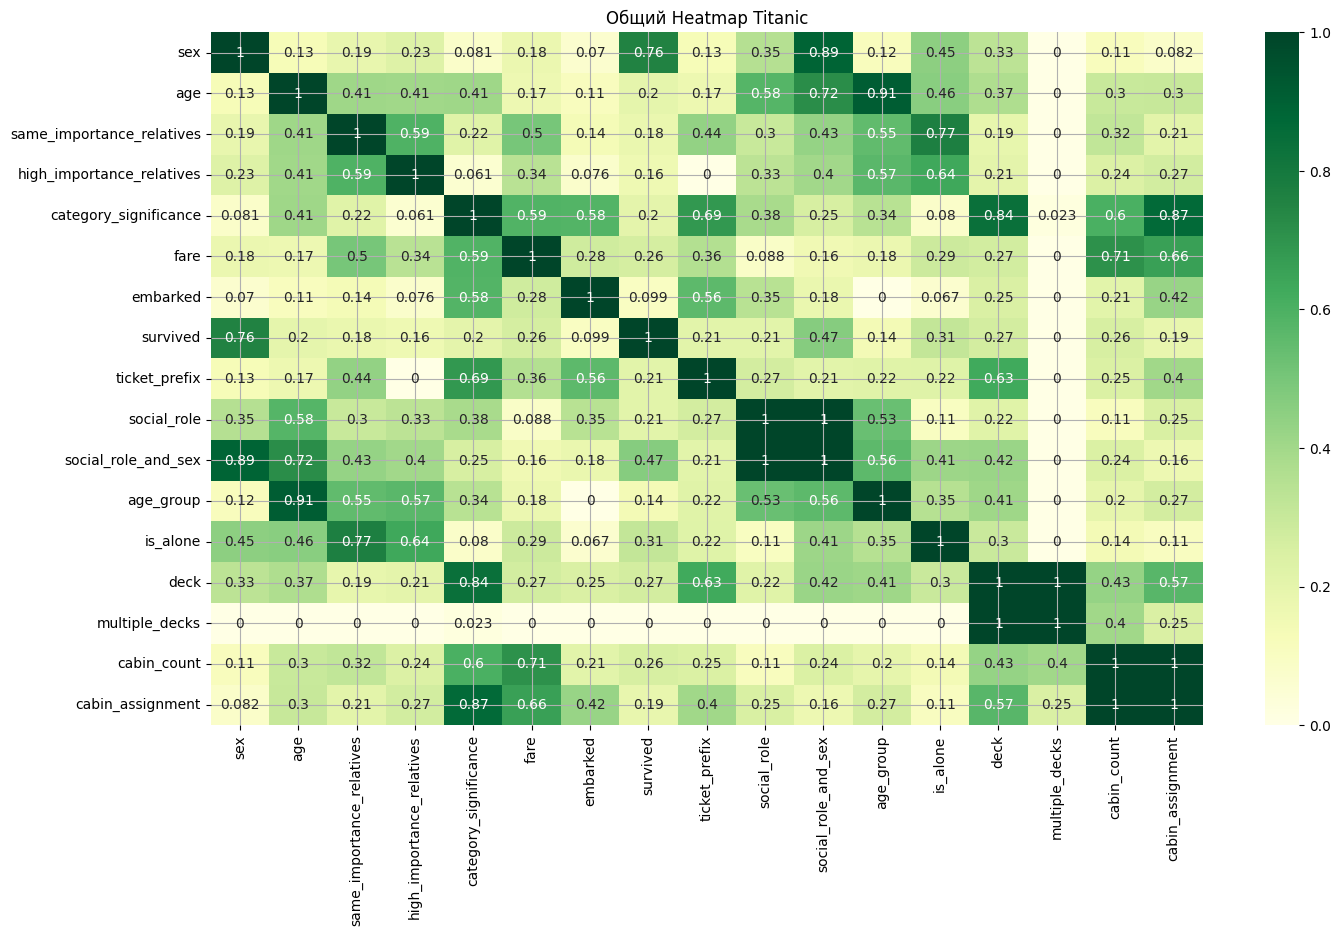

In [13]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    phik_corr_matrix_1,
    annot=True,
    cmap="YlGn",
)

plt.title('Общий Heatmap Titanic')
plt.show()

**Вывод:**


_Нужно проверить есть ли случаи, где у членов семьи разные `ticket_id`._

_По матрице мы видим такие корреляции:_

* _Зависимость `same_importance_relatives` и `high_importance_relatives`, скорее всего, отражает общий скрытый признак семейности пассажира. Гипотеза дополнительно подтверждается высокой корреляцией этих признаков семейности с возрастом (age): дети не могли иметь собственных детей, а взрослые реже путешествовали с братьями и сёстрами, поскольку к этому возрасту чаще уже имели собственные семьи. Зная один из этих признаков, мы можем частично восстановить информацию о семейном статусе пассажира, так как проводя предобработку мы ни раз замечали, что данные естественным образом разделяются на одиночных пассажиров и пассажиров, путешествующих с родственниками. **Необходимо проверить, не скрывается ли за ними общий признак «одиночка / не одиночка»**._

* _Признаки семейности `same_importance_relatives` и `high_importance_relatives`  имеют высокую корреляцию c `ticket_group_size`, поскольку размер группы по билету частично содержит информацию о наличии родственников. При построении модели необходимо учитывать возможное дублирование признаков._

* _`social_role_and_sex` c `sex` достаточно очевидная корреляция, вызванная тем, что, например, роли master у пассажира женского пола быть просто не может, следовательно по одному признаку можно попытаться предсказать второй, но мы в свою очередь создавали этот признак, чтобы попытаться усилить признак `age`, что по итогу нам удалось сделать (по таблице корреляций он мощнее), но `sex` сам по себе имеет куда большую корреляцию с целевым признаком, чем `social_role_and_sex`, поэтому есть вероятность, что `social_role_and_sex` не даст дополнительной информации после добавления `sex` и `age`, так как частично объединяет эти признаки._

* _`social_role_and_sex` связан с семейными признаками, так как содержит информацию о жизненном этапе пассажира, поле и семейном статусе. Поэтому часть его корреляций может объясняться теми же скрытыми факторами, что и у `age`._

* _`survived` c `sex` по причине того, что мужчине в нашей экстренной ситуации выжить сложнее, чем девушке. **Необходимо дополнительно проверить влияние семейного состава, так как наличие родственников могло как повышать, так и снижать вероятность выживания.**_

* _`deck` с полом `sex` и возрастом `age` имеет не очень большую, но значимую корреляцию по неизвестной мне причине. Нужно смотреть детальнее._

* _`deck` с `category_significance` очень интересная зависимость. Вероятно на каких-то палубах условия были лучше._

* _`category_significance` c `fare` тут достаточно очевидно: лучше условия - выше цена._

* _`category_significance` c `embarked` нужно смотреть более детально. Пока не понятно почему категория зависела от порта. Вероятно в каком-то порту покупали исключительно билеты определённой категории._

* `age` с `category_significance`;

* `same_importance_relatives` c `ticket_prefix`;

* `category_significance` c `ticket_prefix`

* _Пока не понятно как относится к этой корреляции `cabin_assignment` и `category_significance`, потому что не понятно как уловить взаимосвязь определённости каюты и категории. Вероятно более дешёвый билет просто чаще брали одиночки._

* `ticket_prefix` с `deck`.

* `ticket_prefix` с `ticket_group_size`, `cabin_assignment`;

* `ticket_prefix` с `embarked`

* `social_role_and_sex` c `deck`, потому что есть какая-то тройная цепочка взаимосвязей палубы с семейностью возрастом и всем прочим, но так или иначе у социальной роли есть скрытая зависимость, из-за которой мы этот признак и создали, поэтому он имеет большую корреляцию с целевым признаком.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div style="text-align: center;">

<h3>Heatmap <code>Titanic</code> по целевому</h3>

</div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 480px;font-weight: 600;">Как устроен мир выжившего и погибшего?</h3></div>


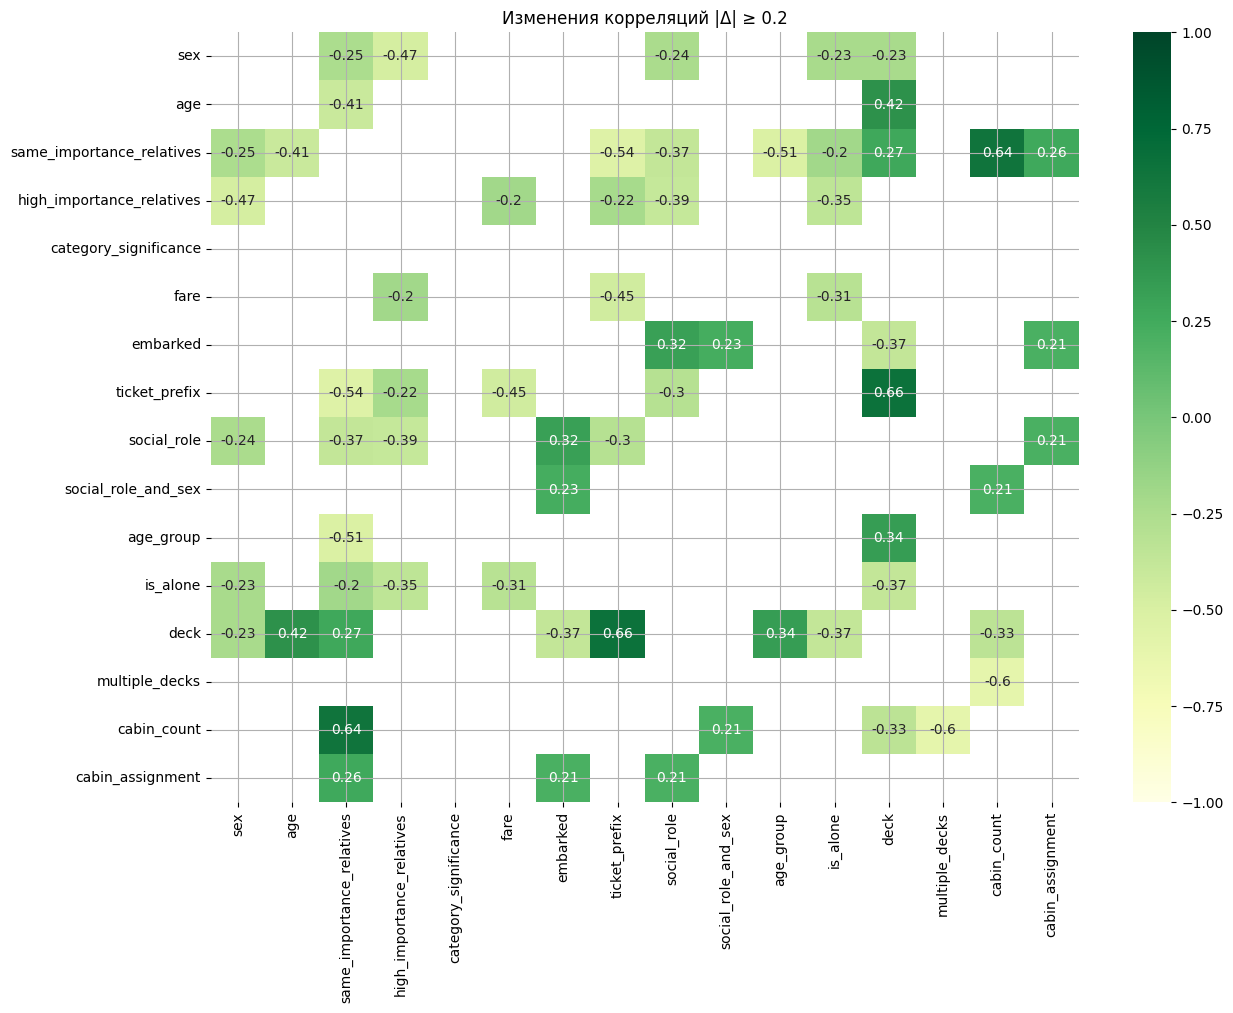

In [14]:
diff = (phik_corr_matrix_2 - phik_corr_matrix_3).round(2)

threshold = 0.2

diff_filtered = diff.where(diff.abs() >= threshold)

plt.figure(figsize=(14, 10))

sns.heatmap(
    diff_filtered,
    annot=True,
    cmap="YlGn",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Изменения корреляций |Δ| ≥ 0.2")
plt.show()

**Вывод:**

Отличия в матрицах, которые требуют дополнительного анализа и поиска скрытых подгрупп:

- _`sex` с `social_role_and_sex` ожидаема, так как социальная роль частично определяется полом пассажира. Например, категории Mr, Mrs, Miss, Master уже содержат информацию о поле и возрастной группе, поэтому высокая корреляция между этими признаками может быть следствием способа формирования признаков. **На этом этапе вернулись и отделили признак от `sex`**;_

-  _`sex` с `high_importance_relatives`, `deck`_
- _`age` с `same_importance_relatives`, `social_role`, `deck`_
- _`same_importance_relatives` с `ticket_prefix`_
- _`high_importance_relatives` с `fare`_
- _`category_significance` c `embarked`_
- _`deck` с `embarked`, признаками семейности_
- _`cabin_assignment` с `embarked`, `social_role`, `same_importance_relatives`._

Среди тех, кто не вижил, пол `sex` сильно связан с палубой `deck`.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 365px;font-weight: 600;">Почему <code>deck</code> связан с <code>sex</code> и <code>age</code></h3></div>


_В ходе исследования было обнаружено, что признак `deck` заполнен преимущественно для пассажиров первой категории обслуживания (для пассажиров второй и третьей категории количество заполненных записей `cabin` составляет всего около 12 наблюдений на группу). Следовательно, часть корреляций `deck` с другими признаками может быть обусловлена не самим расположением каюты, а особенностями состава пассажиров первого класса. Если пассажиры первой категории имеют общие характеристики, выраженные другими признаками, то эти признаки автоматически будут демонстрировать зависимость с `deck`._

_Данные заполнены у 176 пассажиров из 216, которые имеют 1ую категорию значимости, поэтому об этих пассажирах мы в целом можем делать какие-то выводы, но такое маленькое количетсво размеченных данных не даёт нам делать какие-либо выводы о пассажирах в зависимости от палубы в целом._

_Интересно, что пассажиры первого класса практически не были замечены на палубах E,F,G._

_Корреляции с `sex` и `age` намекают на характеристики пассажиров, которые формируют данную зависимость. Посмотрим на них детальнее:_

In [15]:
(
    titanic[
        (titanic['category_significance'] == 1)
    ]['sex'].value_counts()
)

sex
male      122
female     94
Name: count, dtype: int64

**Вывод:**

*Примерно равное соотношение мужчин и женщин.*

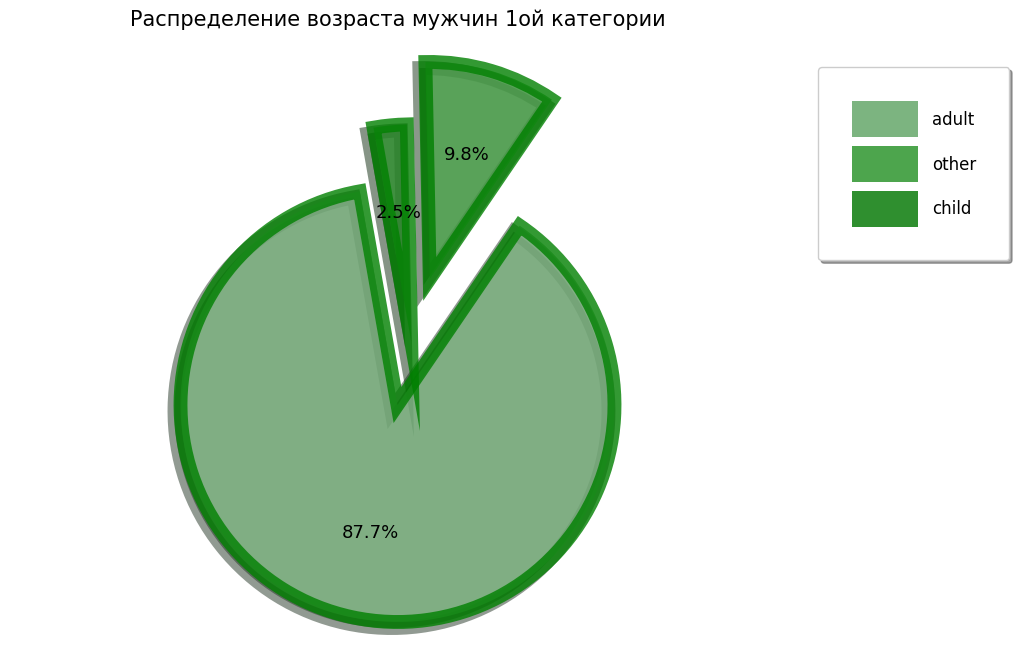

In [16]:
group_name = (
    titanic[
        (titanic['sex'] == 'male') &
        (titanic['category_significance'] == 1)
        ]['social_role'].value_counts()
)

custom_pie_chart(
    data=group_name,
    startangle=100,
    explode=[0.3, 0.3, 0],
    title='Распределение возраста мужчин 1ой категории',
)

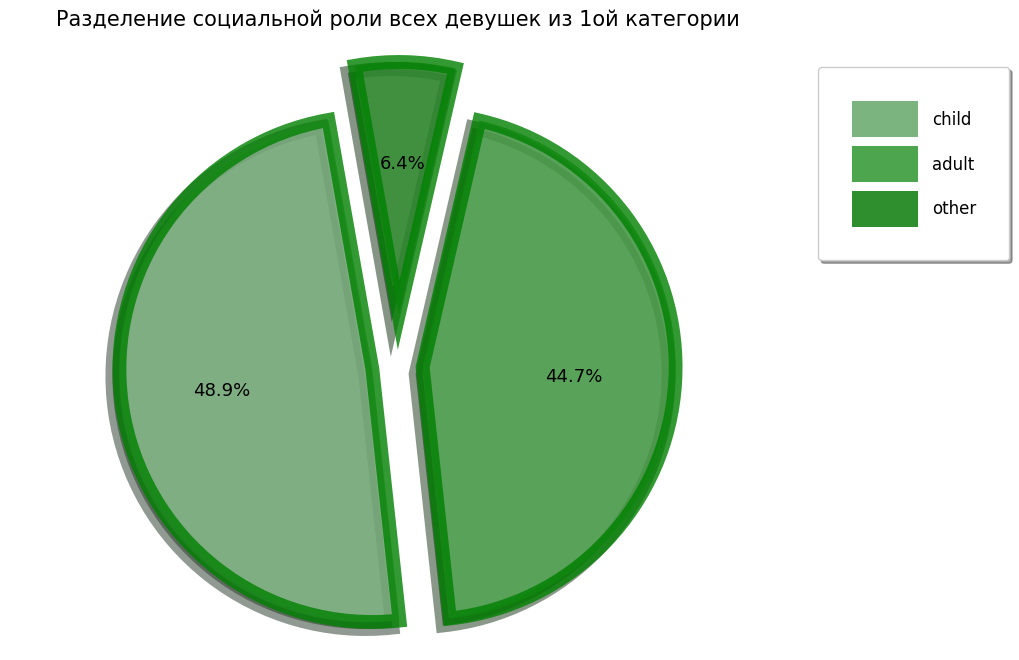

In [17]:
group_name = (
    titanic[
        (titanic['sex'] == 'female') &
        (titanic['category_significance'] == 1)
        ]['social_role'].value_counts()
)

custom_pie_chart(
    data=group_name,
    startangle=100,
    explode=[0.1, 0.1, 0.2],
    title='Разделение социальной роли всех девушек из 1ой категории',
)


**Вывод:**

*В первом классе ехали в целом только взрослые мужчины, из-за чего мы и видим такие корреляции. С женщинами было же уже всё подругому, вероятно, потому что им не часто присуждали социальный статус взрослого по причинам обходящим рождение ребёнка.*

*Среди первого класса были одиночки и не одиночки практически в равном соотношении.*

*Расселение шло по всем палубам.*

*Распределение женщини мужчин в первом классе тоже равное.*

*Посмотрим на состав пассажиров первой категории по палубам и вероятность выживания внутри каждой группы.*

In [18]:
deck_survival = (
    titanic[titanic['category_significance'] == 1]
    .groupby(['deck', 'sex'])
    .agg(
        passengers=('survived', 'count'),
        survival_rate=('survived', 'mean')
    )
)

deck_survival

passengers  survival_rate
deck sex                              
A    female           1       1.000000
     male            14       0.428571
B    female          27       1.000000
     male            20       0.400000
C    female          27       0.888889
     male            32       0.343750
D    female          16       1.000000
     male            13       0.461538
E    female          10       1.000000
     male            15       0.533333
T    male             1       0.000000

**Вывод:**

*Было много палуб, где соотношение мужчин и женщин первого класса практически равное, при этом женщины выживали практически в сто процентном случае. Видно, что от палубы это не зависело.*

_Появляется смещение:_

* _deck заполнена_
*         ↓
* _вероятно дорогой билет_
*         ↓
* _вероятно высокий класс_
*         ↓
* _другой состав пассажиров_

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 590px;font-weight: 600;">Почему <code>embarked</code> связан с <code>category_significance</code></h3></div>


In [19]:
embarked_class = (
    titanic
    .groupby(['embarked', 'category_significance'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

embarked_class

embarked  embarked  category_significance
C         C         1                        0.505952
                    2                        0.101190
                    3                        0.392857
Q         Q         1                        0.025974
                    2                        0.038961
                    3                        0.935065
S         S         1                        0.198437
                    2                        0.256250
                    3                        0.545312
dtype: float64

**Вывод:**

_В порту Q практически все пассажиры приобретали билеты третьей категории обслуживания. Следовательно, именно этот порт формирует обнаруженную корреляцию между `embarked` и `category_significance`._

_В порту C доля пассажиров первой категории оказалась значительно выше, чем в остальных портах: билеты первого класса составляли примерно половину всех приобретённых билетов. Тут было много богатых._

_Порт S имел наиболее смешанный состав пассажиров, однако и здесь преобладала третья категория обслуживания._

_Выходит, мы наткнулись на смещённое распределение признаков._

In [20]:
(
    titanic
    .groupby(
        [
            'category_significance',
            'embarked'
        ]
    )['survived']
    .agg(['count', 'mean'])
)

count      mean
category_significance embarked                 
1                     C            85  0.694118
                      Q             2  0.500000
                      S           127  0.582677
2                     C            17  0.529412
                      Q             3  0.666667
                      S           164  0.463415
3                     C            66  0.378788
                      Q            72  0.375000
                      S           349  0.191977

**Вывод:**

_Мы ответили на вопрос: "Даёт ли порт дополнительную информацию о выживании внутри одной категории обслуживания?". Выходит, что скорее всего нет, поэтому в модели его использовать не стоит._

*Очень большая вероятность, что цены тоже различались в зависимости от порта, но нужно смотреть таблицу, которую мы создали `ticket_group`.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Инженерия признаков (FE)


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Масштабная инженерия</p></div>


*Создадим новую таблицу преобразовав исходную таблицу на иерархию выше с группировкой по идентификатору билета:*


In [21]:
# Интересные поля для нахождения аномалий
# я пометил префиксом watch
# остальные для корреляционного анализа

ticket_group = (
    titanic
    .groupby('ticket_id')
    .agg(
        passenger_count=('passenger_id', 'count'),
        ticket_prefix_watch=('ticket_prefix', 'first'),
        age_mean=('age', 'mean'),
        age_min=('age', 'min'),
        age_max=('age', 'max'),
        fare=('fare', 'first'),
        social_roles_watch=(
            'social_role',
            lambda x: ' | '.join(x.dropna().unique())
        ),
        same_importance_relatives=(
            'same_importance_relatives',
            'sum'
        ),
        surnames_watch=(
            'surname',
            lambda x: ' | '.join(x.dropna().unique())
        ),

        high_importance_relatives=(
            'high_importance_relatives',
            'sum'
        ),
        children_count=(
            'social_role',
            lambda x: (x == "child").sum()
        ),
        deck=(
            'deck',
            'first'
        ),

        deck_watch=(
            'deck',
            lambda x: ' '.join(x.dropna().unique())
        ),

        # исправить
        multiple_decks_watch=(
            'multiple_decks',
            lambda x: ' '.join(x.dropna().unique().astype(str))
        ),
        female_count=(
            'sex',
            lambda x: (x == 'female').sum()
        ),

        male_count=(
            'sex',
            lambda x: (x == 'male').sum()
        ),

        level=('category_significance', 'first'),

        cabins_watch=(
            'cabin',
            lambda x: ' | '.join(x.dropna())
        ),

        cabin_count=(
            'cabin_count',
            'first'
        ),

        embarked=(
            'embarked',
            'first'
        ),

        survival_rate=('survived', 'mean'),
        all_survived=('survived', 'min')
    )
)

ticket_group.head(1)

,passenger_count,ticket_prefix_watch,age_mean,age_min,age_max,fare,social_roles_watch,same_importance_relatives,surnames_watch,high_importance_relatives,...,deck_watch,multiple_decks_watch,female_count,male_count,level,cabins_watch,cabin_count,embarked,survival_rate,all_survived
ticket_id,,,,,,,,,,,,,,,,,,,,,
110152,3,NO_PREFIX,26.333334,16.0,33.0,86.5,child | other,0,Cherry | Maioni | Rothes,0,...,B,0,3,0,1,B77 | B79 | B77,1,S,1.0,1


*Создадим таблицу, где встречается аномалия: несколько фамилий записаны на один билет.*

In [22]:
related_surnames = (
    ticket_group[
        ticket_group['surnames_watch'].str.contains('|', regex=False)
    ]
)

related_surnames.head(1)

,passenger_count,ticket_prefix_watch,age_mean,age_min,age_max,fare,social_roles_watch,same_importance_relatives,surnames_watch,high_importance_relatives,...,deck_watch,multiple_decks_watch,female_count,male_count,level,cabins_watch,cabin_count,embarked,survival_rate,all_survived
ticket_id,,,,,,,,,,,,,,,,,,,,,
110152,3,NO_PREFIX,26.333334,16.0,33.0,86.5,child | other,0,Cherry | Maioni | Rothes,0,...,B,0,3,0,1,B77 | B79 | B77,1,S,1.0,1


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Единичная инженерия</p></div>


In [23]:
titanic['ticket_group_size'] = (
    titanic.groupby('ticket_id')['ticket_id']
    .transform('count')
    .astype('uint8')
)

titanic.head(1)

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,...,social_role_and_sex,surname,name_custom,age_group,is_alone,deck,multiple_decks,cabin_count,cabin_assignment,ticket_group_size
0,1,A/5 21171,"Braund, Mr. Owen Harris",male,22.0,1,0,3,7.25,NaN,...,adult_man,Braund,Owen Harris,young_adult,0,NaN,0,0,0,1


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Масштабная инженерия</p></div>


*Создадим новую таблицу преобразовав исходную таблицу на иерархию выше с группировкой по фамилии:*

In [24]:
# Одни столбцы я создавал для глубокого анализа руками
# Другие - для анализа корреляций

family_group = (
    titanic
    .groupby('surname')
    .agg(
        family_size=('passenger_id', 'count'),
        age_mean=('age', 'mean'),
        age_min=('age', 'min'),
        age_max=('age', 'max'),
        fare=('fare', 'first'),

        ticket_count=('ticket_id', 'nunique'),
        tickets_watch=(
            'ticket_id',
            lambda x: ' | '.join(x.dropna().unique()),
        ),

        social_roles_watch=(
            'social_role',
            lambda x: ' | '.join(x.dropna().unique())
        ),

        same_importance_relatives=(
            'same_importance_relatives',
            'sum'
        ),

        high_importance_relatives=(
            'high_importance_relatives',
            'sum'
        ),

        deck_count=('deck', 'nunique'),

        multiple_decks=(
            'multiple_decks',
            lambda x: x.any()
        ),

        multiple_decks_watch=(
            'multiple_decks',
            lambda x: ' '.join(x.dropna().unique().astype(str)),
        ),

        decks_watch=(
            'deck',
            lambda x: ' '.join(x.dropna().unique())
        ),

        female_count=(
            'sex',
            lambda x: (x == 'female').sum()
        ),

        male_count=(
            'sex',
            lambda x: (x == 'male').sum()
        ),

        child_count=(
            'age',
            lambda x: (x < 18).sum()
        ),

        category_significance=('category_significance', 'first'),

        cabins_watch=(
            'cabin',
            lambda x: ' | '.join(x.dropna())
        ),
        cabin_count=(
            'cabin_count',
            'first'
        ),

        survival_rate=('survived', 'mean'),
        all_survived=('survived', 'min')
    )
)

family_group.head(1)

,family_size,age_mean,age_min,age_max,fare,ticket_count,tickets_watch,social_roles_watch,same_importance_relatives,high_importance_relatives,...,multiple_decks_watch,decks_watch,female_count,male_count,child_count,category_significance,cabins_watch,cabin_count,survival_rate,all_survived
surname,,,,,,,,,,,,,,,,,,,,,
Abbing,1,42.0,42.0,42.0,7.55,1,C.A. 5547,adult,0,0,...,0,,0,1,0,3,,0,0.0,0


*На данном этапе хочется также пострить:*

1. *таблицу сгруппированную по палубам для анализа закономерностей на уровне палуб корабля (размещения пассажиров по палубам)*

2. *таблицу сгруппированную по каютам для анализа закономерностей на уровне кают корабля (размещения пассажиров по каютам)*

*Это поможет нам изучить кейс титаник ещё лучше.*

*Но на данный момент признак `cabin` является самым грязным признаком в выборке. Если пассажиров с кабинами 200 человек, я начну делать по ним выводы, сделаю вывод, к примеру, в каюте жили в основнмо женщины, то это будет вывод ровно о тех, у кого сохранились записи кабин, а не по всем пассажирам.*

*Достроим таблицы после углубленной предобработки, когда пропуски в данных будут устранены.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Единичная инженерия</p></div>


Напишем функцию, которая позволит разделить семьи из таблицы на типы: только мужчина без детей, только женщина без детей, только дети, только мужчина и женщина, женщина с детьми, мужчина с детьми, мужчина и женщина с детьми, другое.

In [25]:
def get_family_type(row):
    male = row['male_count']
    female = row['female_count']
    child = row['child_count']

    if male > 0 and female == 0 and child == 0:
        return 'only_men'

    elif female > 0 and male == 0 and child == 0:
        return 'only_women'

    elif child > 0 and male == 0 and female == 0:
        return 'only_children'

    elif male > 0 and female > 0 and child == 0:
        return 'men_women'

    elif female > 0 and child > 0 and male == 0:
        return 'women_children'

    elif male > 0 and child > 0 and female == 0:
        return 'men_children'

    elif male > 0 and female > 0 and child > 0:
        return 'men_women_children'

    else:
        return 'other'

In [26]:
family_group['family_type'] = (
    family_group.apply(get_family_type, axis=1)
)

family_group.head(1)

,family_size,age_mean,age_min,age_max,fare,ticket_count,tickets_watch,social_roles_watch,same_importance_relatives,high_importance_relatives,...,decks_watch,female_count,male_count,child_count,category_significance,cabins_watch,cabin_count,survival_rate,all_survived,family_type
surname,,,,,,,,,,,,,,,,,,,,,
Abbing,1,42.0,42.0,42.0,7.55,1,C.A. 5547,adult,0,0,...,,0,1,0,3,,0,0.0,0,only_men


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Масштабная инженерия</p></div>


_Соединим семейные признаки с основной таблицей Titanic._

In [27]:
family_features = (
    family_group
    [
        [
            'family_size',
            'female_count',
            'male_count',
            'child_count',
            'family_type',
        ]
    ]
    .reset_index()
)

family_features.head(1)

,surname,family_size,female_count,male_count,child_count,family_type
0,Abbing,1,0,1,0,only_men


In [28]:
print('Размер до трансформации', titanic.shape)

titanic = titanic.merge(
    family_features,
    on='surname',
    how='left'
)

print('Размер после трансформации', titanic.shape)

Размер до трансформации (887, 25)
Размер после трансформации (887, 30)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Иерархические исследования (EDA)


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 436px;font-weight: 600;">Подготовка и настройка инструментов</h3></div>


In [29]:
drop_cols_for_ticket_group = [
    'cabins_watch', 'deck_watch', 'social_roles_watch',
    'surnames_watch', 'multiple_decks_watch'
]

interval_cols_for_ticket_group = [
    'age_min', 'age_mean', 'age_max', 'same_importance_relatives', 'high_importance_relatives', 'female_count',
    'male_count', 'child_count', 'fare', 'passenger_count',
]

drop_cols_for_family_group = [
    'tickets_watch', 'social_roles_watch',
    'multiple_decks_watch', 'decks_watch',
    'cabins_watch'
]

interval_cols_for_family_group = [
    'age_min', 'age_mean', 'age_max', 'male_count',
    'same_importance_relatives', 'child_count',
    'high_importance_relatives', 'female_count',
    'deck_count', 'family_size', 'ticket_count',
    'cabin_count', 'fare'
]

phik_corr_matrix_4 = phik_matrix(
    ticket_group.drop(columns=drop_cols_for_ticket_group),
    interval_cols=interval_cols_for_ticket_group
)

phik_corr_matrix_5 = phik_matrix(
    family_group.drop(columns=drop_cols_for_family_group),
    interval_cols=interval_cols_for_family_group
)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div style="text-align: center;">

<h3>Heatmap <code>Ticket_group</code> общий</h3>

</div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 495px;font-weight: 600;">Какие связи после группировки по билетам?</h3></div>


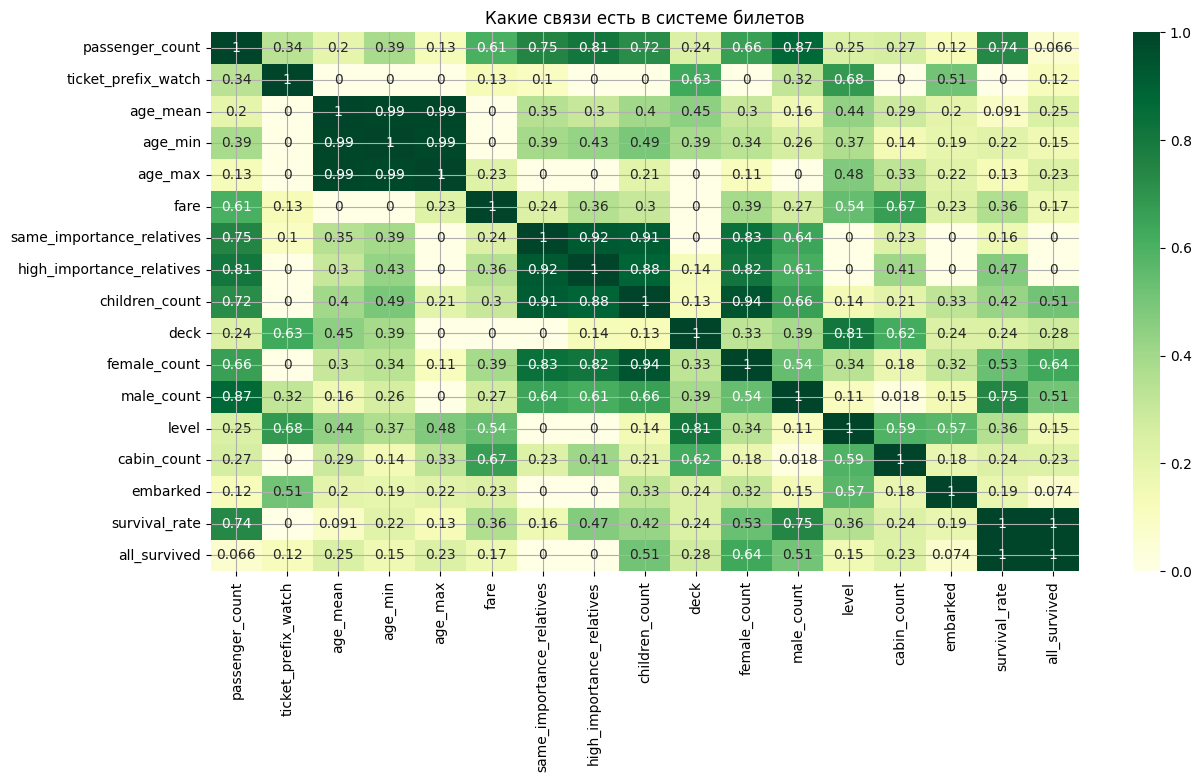

In [30]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    phik_corr_matrix_4,
    annot=True,
    cmap="YlGn",
)

plt.title('Какие связи есть в системе билетов')
plt.show()

**Вывод:**


_Какие корреляции заметны по карте:_

* _Несколько очевидных корреляций признака `passenger_count` с теми признаками, которые также указывают на количество людей в билете, Больше ничего интересного об этом признаке из матрицы подчеркнуть не получается;_
* _`age` с `category_significance` по причине того, что билеты первой категории чаще покупали люди более взрослые. Остальные категории шли на уменьшение возраста с определённым интервалом, из-за чего выстраивалась градация. **Уже изучена**_
* _`age_min` с `child_count` имеет достаточно большую корреляцию. child_count = количество пассажиров в группе с age < X. Если в группе есть ребёнок → вероятность маленького age_min резко возрастает. Признаки частично дублируют информацию о возрастной структуре группы. **При дальнейшем построении модели необходимо учитывать избыточность этих признаков.**_
* _Любопытно, что `fare` имеет лёгкую зависимость с количеством мужчин и женщин, но при этом с количеством детей зависимость абсолютно нулевая. Эти признаки изначально были образованы от разных признаков. Признак `child_count` образован от `age`. **Нужно смотреть подробнее**_
* _Больше всего на цену `fare` влияла категория значимости и количество пасажиров. В целом, если категория значимости - это определённый диапазон цены, то мы можем заполнить пропуски в `deck` в зависимости от цены. **Нужно смотреть подробнее**_
* _Очень стойкую зависимость имеет `deck` c `child_count` из-за связи с полом._

**В основном данная таблица лишь подтвердила отсутствие некоторых направлений поиска. Изначальная цель её построения заключалась в том, что она улучшает смещение метрик для `fare`, что должно более чётко показать её составляющие. Также цель получить немного более полную картину по `deck`. По матрице лишь более чётко видно, что она зависит от всех признаков, которые так или иначе были связаны с категорией значимости.**

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 280px;font-weight: 600;">Что происходит с <code>fare</code></h3></div>


Есть ли вообще единая цена? От чего зависит fare, чтобы понять, можно ли использовать его для восстановления deck и других пропусков?

In [31]:
ticket_group[
    (ticket_group["passenger_count"] == 1) &
    (ticket_group["level"] == 3) &
    (ticket_group["fare"] > 0) &
    (ticket_group["female_count"] == 1) &
    (ticket_group["same_importance_relatives"] == 0) &
    (ticket_group["high_importance_relatives"] == 0)
    ][
    [
        'age_min', 'social_roles_watch',
        'deck_watch', 'cabins_watch', 'fare', 'embarked'
    ]
].sort_values('fare')

,age_min,social_roles_watch,deck_watch,cabins_watch,fare,embarked
ticket_id,,,,,,
365226,18.0,child,,,6.7500,Q
2667,15.0,child,,,7.2250,C
2649,NaN,adult,,,7.2250,C
2626,NaN,adult,,,7.2292,C
2687,13.0,child,,,7.2292,C
C 7077,22.0,child,,,7.2500,S
3101265,18.0,child,,,7.4958,S
CA. 2314,23.0,child,,,7.5500,S
W./C. 6609,NaN,child,,,7.5500,S


**Вывод:**

Заметно, что какой-то детской скидки тут точно нет:
* age 18
* fare 6.75
* age 15
* fare 7.225
* age 30.5
* fare 7.75
* age 45
* fare 7.75

_Это исследование я начал исходя их того, что признак `fare` по всем соображениям из матриц и прочих проведённых исследований имеет очень детализированную структуру. Сказать, что он был заполнен с отсутствием логики я не могу, потому что она здесь так или иначе прослеживается, когда заметны билеты с ticket_id идущими друг за другом с одинаковой ценой или те, где были одинаковые кабины, порты и другие данные, но присутствует лёгкое различие в стоимости._



_В ходе анализа было установлено, что наибольшую часть вариации стоимости билета объясняет категория обслуживания (`level`). Однако внутри каждой категории сохраняется дополнительный разброс стоимости, особенно заметный для пассажиров первого класса. Поэтому были исследованы дополнительные признаки, потенциально влияющие на формирование `fare`._

_`level` + `passenger_count` + `cabin_count` + `ticket_prefix`_

_Порт посадки я уже проверил и оказалось, что он не влияет на цену, хотя это было очень вероятно. Могли, конечно, запустить корабль по круговому маршруту и брать всегда с учётом конечного пункта или пункта начала, но этого нет. Порта высадки у нас тоже нет, соответственно просто отбросим этот признак._

In [32]:
(
    ticket_group
    .groupby('level')['fare']
    .describe()
    .loc[:, ['count', '25%', '50%', '75%']]
)

,count,25%,50%,75%
level,,,,
1,147.0,28.125,49.5042,78.55835
2,140.0,12.350,13.0000,26.00000
3,393.0,7.750,7.8958,8.71250


_То есть, причина, по которой мне хочется что-то с этим сделать, заключается в очень большом разбросе от min до max внути каждой категории за исключением: третьего класса, который был достаточно стандартизирован._

In [33]:
level_passengers_count_group = (
    ticket_group
    .groupby(['level', 'passenger_count'])['fare']
    .describe()
    .loc[:, ['count', 'min', '25%', '50%', '75%', 'max']]
)

level_passengers_count_group

count       min         25%        50%        75%  \
level passenger_count                                                      
1     1                 97.0    0.0000   26.550000   30.50000   49.50420   
      2                 36.0   31.0000   56.671900   79.02500   91.68440   
      3                  9.0   76.7292   79.650000  113.27500  153.46250   
      4                  5.0  110.8833  120.000000  151.55000  227.52500   
2     1                107.0    0.0000   11.500000   13.00000   13.50000   
      2                 24.0   10.5000   22.500000   26.00000   29.26770   
      3                  8.0    0.0000   24.187500   26.25000   29.06250   
      5                  1.0   73.5000   73.500000   73.50000   73.50000   
3     1                343.0    4.0125    7.733300    7.89580    8.05000   
      2                 34.0    9.2167   14.455225   15.79585   17.95000   
      3                  4.0   11.1333   18.177075   22.33750   24.15000   
      4                  5.0    0.0000   19.258300   21.07500   25.46670   
      5                  1.0   29.1250   29.125000   29.12500   29.12500   
      6                  3.0   27.9000   33.793750   39.68750   43.29375   
      7                  3.0   31.2750   43.885400   56.49580   63.02290   

                            max  
level passenger_count            
1     1                221.7792  
      2                262.3750  
      3                512.3292  
      4                263.0000  
2     1                 32.5000  
      2                 65.0000  
      3                 41.5792  
      5                 73.5000  
3     1                 22.5250  
      2                 24.1500  
      3                 24.1500  
      4                 31.3875  
      5                 29.1250  
      6                 46.9000  
      7                 69.5500

In [34]:
level_passengers_count_group[
    level_passengers_count_group['count'] > 9
    ]

count      min        25%       50%      75%       max
level passenger_count                                                        
1     1                 97.0   0.0000  26.550000  30.50000  49.5042  221.7792
      2                 36.0  31.0000  56.671900  79.02500  91.6844  262.3750
2     1                107.0   0.0000  11.500000  13.00000  13.5000   32.5000
      2                 24.0  10.5000  22.500000  26.00000  29.2677   65.0000
3     1                343.0   4.0125   7.733300   7.89580   8.0500   22.5250
      2                 34.0   9.2167  14.455225  15.79585  17.9500   24.1500

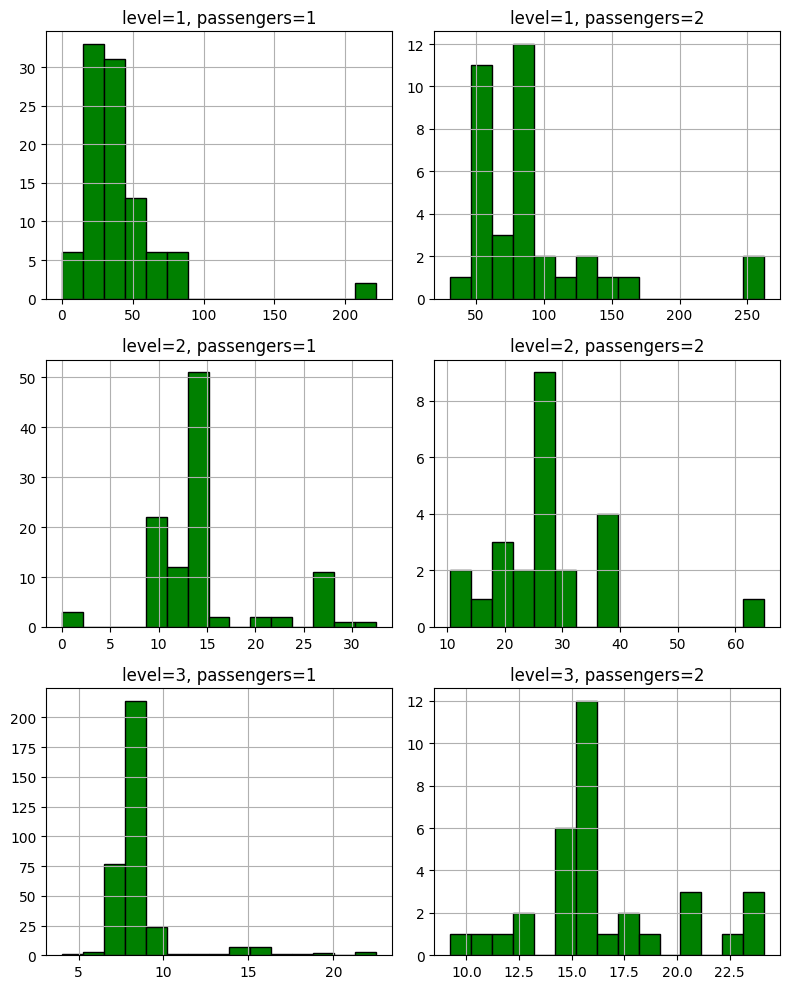

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

axes = axes.ravel()

for ax, ((level, passenger_count), fares) in zip(
        axes,
        (
                ticket_group[ticket_group['passenger_count'] < 3]
                        .groupby(
                    ['level', 'passenger_count']
                )['fare']
        )
):
    fares.hist(
        ax=ax,
        bins=15,
    )
    ax.set_title(f'level={level}, passengers={passenger_count}')

plt.tight_layout()

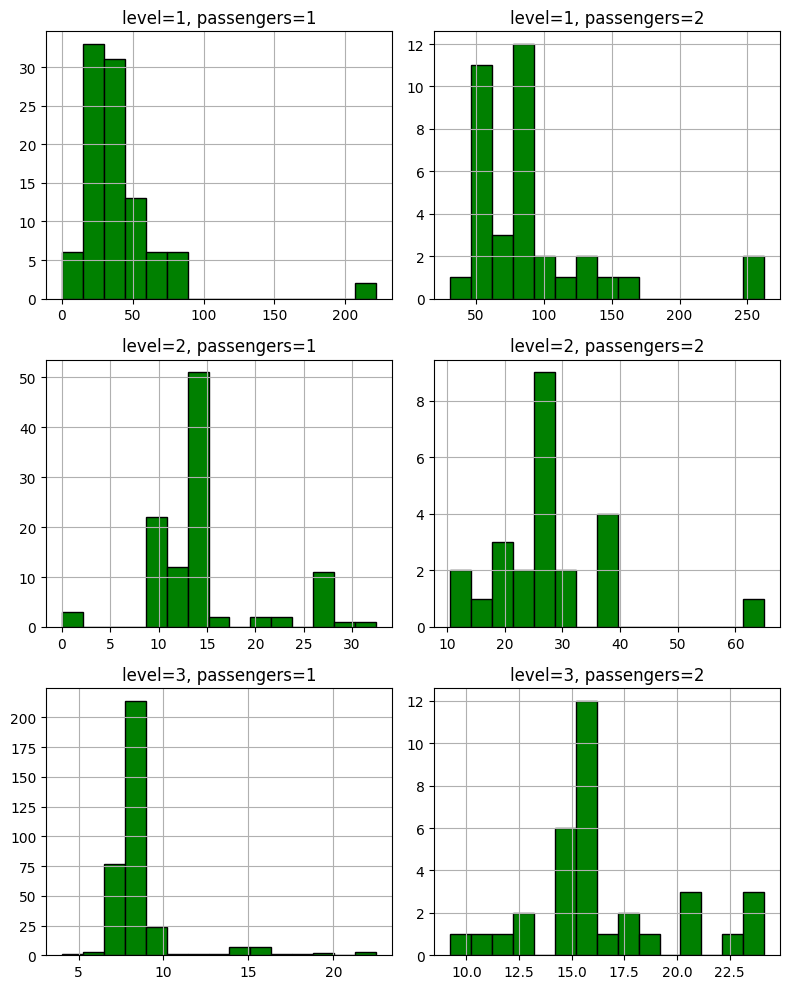

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

axes = axes.ravel()

for ax, ((level, passenger_count), fares) in zip(
        axes,
        (
                ticket_group[ticket_group['passenger_count'] < 3]
                        .groupby(
                    ['level', 'passenger_count']
                )['fare']
        )
):
    fares.hist(
        ax=ax,
        bins=15,
    )
    ax.set_title(f'level={level}, passengers={passenger_count}')

plt.tight_layout()

In [37]:
ticket_group_by_cabins = (
    ticket_group[
        (ticket_group['cabin_count'] > 0)  # 0 - это пропуски
    ]
    .groupby(
        ['level', 'cabin_count', 'passenger_count', ]
    )['fare'].describe()
    .loc[:, ['count', 'min', '25%', '50%', '75%', 'max']]

)

ticket_group_by_cabins

count       min         25%       50%  \
level cabin_count passenger_count                                          
1     1           1                 72.0    0.0000   26.550000   30.5979   
                  2                 28.0   52.0000   56.671900   77.7771   
                  3                  8.0   76.7292   79.227075   99.8875   
      2           1                  1.0   63.3583   63.358300   63.3583   
                  2                  1.0  247.5208  247.520800  247.5208   
                  4                  2.0  120.0000  127.887500  135.7750   
      3           1                  1.0    5.0000    5.000000    5.0000   
                  4                  1.0  263.0000  263.000000  263.0000   
      4           2                  1.0  262.3750  262.375000  262.3750   
2     1           1                 10.0   10.5000   10.962500   12.9375   
                  2                  2.0   10.5000   17.625000   24.7500   
                  3                  1.0   26.0000   26.000000   26.0000   
3     1           1                  2.0    7.7500    7.825000    7.9000   
                  2                  3.0   10.4625   11.468750   12.4750   
      2           1                  3.0    7.6500    7.650000    7.6500   
                  2                  1.0   22.3583   22.358300   22.3583   

                                         75%       max  
level cabin_count passenger_count                       
1     1           1                 50.12395  221.7792  
                  2                 90.00000  164.8667  
                  3                140.09060  211.3375  
      2           1                 63.35830   63.3583  
                  2                247.52080  247.5208  
                  4                143.66250  151.5500  
      3           1                  5.00000    5.0000  
                  4                263.00000  263.0000  
      4           2                262.37500  262.3750  
2     1           1                 13.00000   13.7917  
                  2                 31.87500   39.0000  
                  3                 26.00000   26.0000  
3     1           1                  7.97500    8.0500  
                  2                 14.58750   16.7000  
      2           1                  7.65000    7.6500  
                  2                 22.35830   22.3583

_Существуют ли разные тарифы внутри класса?_

In [38]:
ticket_group_by_prefix = (
    ticket_group
    .groupby(
        ['level', 'ticket_prefix_watch']
    )['fare'].describe()
    .loc[:, ['count', 'min', '25%', '50%', '75%', 'max']]
)

ticket_group_by_prefix[
    ticket_group_by_prefix['count'] > 1
    ].sort_values(['level', '50%'])

count     min        25%      50%         75%  \
level ticket_prefix_watch                                                  
1     NO_PREFIX            104.0   0.000  26.550000  39.0500   75.510425   
      pc                    39.0  25.925  29.206250  61.3792  107.662500   
      wep                    2.0  61.175  63.631250  66.0875   68.543750   
2     ca                    14.0  10.500  10.500000  10.5000   15.062500   
      swpp                   2.0  10.500  10.500000  10.5000   10.500000   
      wc                     3.0  10.500  10.500000  10.5000   10.500000   
      NO_PREFIX             97.0   0.000  13.000000  13.0000   26.000000   
      scparis                8.0  12.875  13.861450  15.0479   30.041650   
      fcc                    3.0  10.500  15.750000  21.0000   23.625000   
      LINE                   2.0  13.000  18.000000  23.0000   28.000000   
      scah                   2.0  26.000  26.000000  26.0000   26.000000   
      soc                    2.0  10.500  26.250000  42.0000   57.750000   
3     c                      5.0   6.450   7.141700   7.2500    7.250000   
      sotonoq               15.0   7.050   7.050000   7.2500    8.050000   
      sotono                 2.0   7.125   7.325000   7.5250    7.725000   
      NO_PREFIX            310.0   0.000   7.750000   7.8958    9.222925   
      stono                 17.0   7.125   7.925000   7.9250    7.925000   
      a                     26.0   7.250   7.749975   8.0500    8.050000   
      pp                     2.0   9.350  11.187500  13.0250   14.862500   
      wc                     2.0   7.550  11.525000  15.5000   19.475000   
      ca                     8.0   7.550  13.212500  18.0750   27.156250   

                                max  
level ticket_prefix_watch            
1     NO_PREFIX            263.0000  
      pc                   512.3292  
      wep                   71.0000  
2     ca                    36.7500  
      swpp                  10.5000  
      wc                    10.5000  
      NO_PREFIX             65.0000  
      scparis               41.5792  
      fcc                   26.2500  
      LINE                  33.0000  
      scah                  26.0000  
      soc                   73.5000  
3     c                     22.5250  
      sotonoq                8.0500  
      sotono                 7.9250  
      NO_PREFIX             56.4958  
      stono                 15.8500  
      a                     24.1500  
      pp                    16.7000  
      wc                    23.4500  
      ca                    69.5500

**Вывод:**

* _Признак `level` - главный фактор. Очень сильно стандартизирует диапазоны и даёт основной результат для достаточно точного попадаения в цену;_
* _Признак `passenger_count` ещё сильнее стандартизирует диапазоны цен в совокупности с признаком `level`;_
* _Дополнительные признаки (`ticket_prefix`, `embarked`, `cabin_count`) дают локальные различия внутри отдельных групп, однако их влияние значительно слабее. Хорошо объяснят многие самые скрытые аномалии. Добавляет немного информации._
* _`cabin_count` при том, что имеет достаточно большую корреляцию, ведёт себя странновато._

_Несмотря на наличие некоторой зависимости между `fare` и `deck`, стоимость билета не позволяет однозначно восстановить палубу, поскольку одинаковые диапазоны цен встречаются на разных палубах. Поэтому использовать fare как единственный источник заполнения пропусков deck некорректно._

_Добавление признака `ticket_group_size` в основную таблицу должно хорошо сказаться._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 450px;font-weight: 600;">Почему <code>ticket_prefix</code> связан с <code>deck</code></h3></div>


_Посмотрим сколько уникальных групп существует и какие группы попадались чаще._

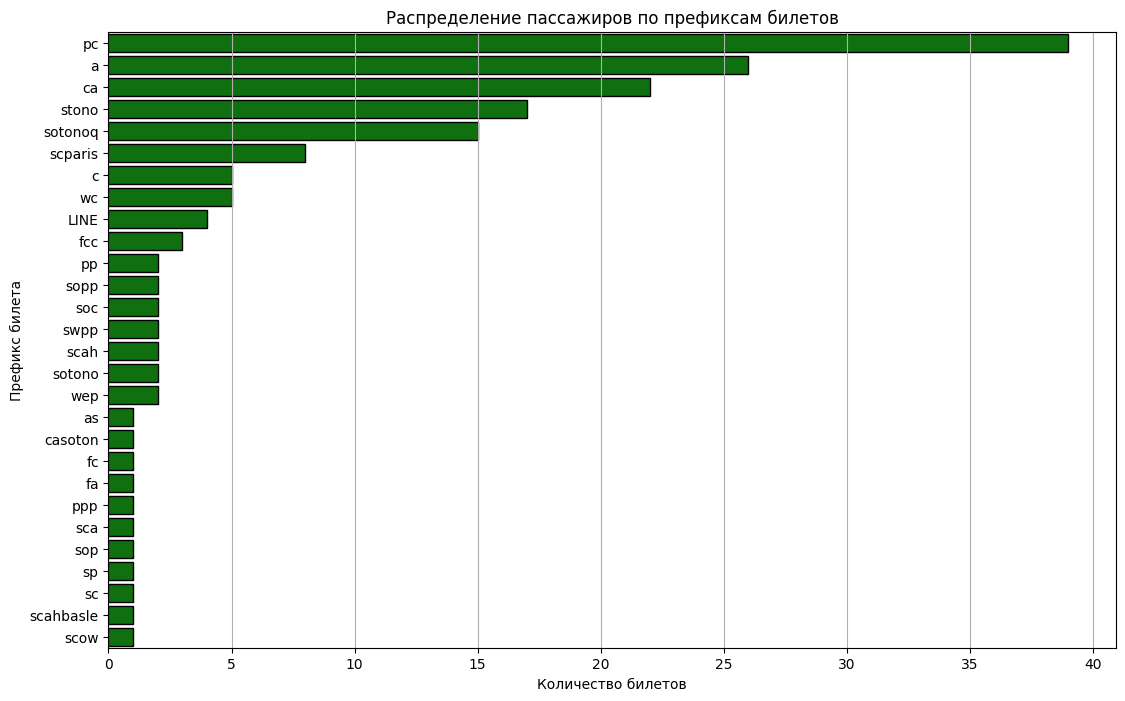

In [39]:
plt.figure(figsize=(13, 8))

prefix_data = (
    ticket_group[
        ticket_group['ticket_prefix_watch'] != 'NO_PREFIX'
        ]
)

sns.countplot(
    y='ticket_prefix_watch',
    data=prefix_data,
    order=prefix_data['ticket_prefix_watch'].value_counts().index,
)

plt.title('Распределение пассажиров по префиксам билетов')
plt.ylabel('Префикс билета')
plt.xlabel('Количество билетов')

plt.show()

_Уникальность префиксов по категориям_

In [40]:
level_1_prefix = set(
    ticket_group[ticket_group['level'] == 1]['ticket_prefix_watch']
)
level_2_prefix = set(
    ticket_group[ticket_group['level'] == 2]['ticket_prefix_watch']
)
level_3_prefix = set(
    ticket_group[ticket_group['level'] == 3]['ticket_prefix_watch']
)

common_all = level_1_prefix & level_2_prefix & level_3_prefix

common_all

{'LINE', 'NO_PREFIX'}

**Вывод:**

_Видим, что практически все префиксы были уникальны под каждую категорию значимости, соответственно их имеет смысл анализировать только отдельно. Самостоятельная ценность `ticket_prefix` сильно уменьшается._

*Есть ли различия между prefix внутри одного level?*

In [41]:
(
    ticket_group[
        (ticket_group['ticket_prefix_watch'].isin(
            ['pc', 'ca', 'scparis', 'a', 'sotonoq', 'stono']
        )) &
        (ticket_group['passenger_count'] == 1)
        ]
    .groupby(['ticket_prefix_watch', 'level'])
    .agg(
        age=('age_mean', 'mean'),
        fare=('fare', 'median'),
        female_ratio=('female_count', 'mean'),
        survival=('survival_rate', 'mean')
    )
)

age      fare  female_ratio  survival
ticket_prefix_watch level                                             
a                   3      29.289474   8.05000      0.041667  0.083333
ca                  2      37.090908  10.50000      0.363636  0.363636
                    3      32.500000   7.55000      0.333333  0.333333
pc                  1      41.000000  32.67500      0.333333  0.500000
scparis             2      28.750000  14.45415      0.166667  0.333333
sotonoq             3      26.600000   7.25000      0.066667  0.133333
stono               3      27.937500   7.92500      0.250000  0.437500

*Можно попробовать создать признак, если количество пассажиров меньше 3ёх и человек имел один из preffix, то человек подвергался слегка изменённым условиям.*

*Посмотрим на причину корреляции с deck:*

In [42]:
group = (
    ticket_group[ticket_group['deck_watch'] != '']
)

print(
    'Размер группы:',
    len(group)
)

pd.crosstab(
    group['ticket_prefix_watch'],
    group['deck_watch']
)

Размер группы: 142


deck_watch,A,B,C,C A,D,E,E A,E_F,F,F_G,G,T
ticket_prefix_watch,,,,,,,,,,,,
NO_PREFIX,11,19,28,1,19,16,0,1,4,3,1,1
ca,0,0,0,0,0,0,0,0,2,0,0,0
fc,0,1,0,0,0,0,0,0,0,0,0,0
pc,2,7,10,0,3,5,1,0,0,0,0,0
pp,0,0,0,0,0,0,0,0,0,0,1,0
scahbasle,0,0,0,0,1,0,0,0,0,0,0,0
scparis,0,0,0,0,1,0,0,0,0,0,0,0
sopp,0,0,0,0,0,1,0,0,0,0,0,0
sotonoq,0,0,0,0,0,1,0,0,0,0,0,0


**Вывод:**

_Выходит зависимость простая, чем больше пропусков, тем больше вероятность, что `ticket_prefix` != pc или NO_PREFIX. Тоже самое можно сразу сказать и про корреляцию с `cabin_assignment`._

_`ticket_prefix` имеет связь с `deck`, но помочь в заполнении пропусков._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 500px;font-weight: 600;">Как палуба или кабина влияла на комфорт</h3></div>


Есть ли зависимость цены от палубы внутри одного класса `category_significance`

In [43]:
first_class = ticket_group[
    ticket_group['level'] == 1
    ]

(
    first_class[first_class['fare'] > 0]
    .groupby('deck')['fare']
    .describe()
    .sort_values('50%', ascending=False)
)

,count,mean,std,min,25%,50%,75%,max
deck,,,,,,,,
B,26.0,100.434296,106.790434,5.0000,37.50000,70.1500,92.894800,512.3292
C,39.0,82.272864,64.624203,26.5500,30.25000,53.1000,107.662500,263.0000
D,20.0,54.618545,24.443018,25.9292,31.74060,52.5542,76.401075,113.2750
E,19.0,49.247589,27.894454,25.5875,26.46875,51.8625,56.414600,134.5000
A,12.0,40.452425,15.053372,26.0000,30.92395,35.5000,42.593750,81.8583
T,1.0,35.500000,NaN,35.5000,35.50000,35.5000,35.500000,35.5000


_После перехода к билетам различия между палубами стали меньше, потому что раньше билет, по которому ехали 4 человека, учитывался 4 раза. Теперь он учитывается 1 раз. Предположение о том, что таблица была смещена количеством пассажиров подтвердилось._

*Если бы цена определяла палубу, мы ожидали бы что-то вроде A > B > C > D > E, но здесь, смотря на медианы, подобного эффекта не видно*

_Теперь осталось выяснить есть ли скрытый фактор, который может объяснить стоимость билета через размер каюты._

**Вывод:**

_Скорее всего все отличия кабин уже заложены в признак категория значимости и связи с комфортом или стоимостью не было никакой._

_Признак `deck` и `cabin` заполнить просто не возможно, потому что все предыдущие исследования показали:_

* _связь с `category_significance` существовала только из-за аномалии заполнения `deck` (были заполнены преимущественно кабины первого класса);_
* _связь со стоимостью исчезает как только смещается распределение, о чём ещё раз говорят сгруппированные таблицы;_
* _Связь с `age` просто дублирует связь от `category_significance`, которая говорила нам о том, что 1ую категорию могли себе позволить более взрослые люди;_
* _Связь с `sex` показывает нам аномалию, что одна палуба была заполнена исключительно мужчинами._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 360px;font-weight: 600;">Несколько семей на один билет</h3></div>


In [44]:
related_surnames['same_importance_relatives'].value_counts()

same_importance_relatives
0    28
1     7
2     7
3     1
6     1
Name: count, dtype: int64

In [45]:
titanic[titanic['ticket_id'] == 'S.O.C. 14879']

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,...,deck,multiple_decks,cabin_count,cabin_assignment,ticket_group_size,family_size,female_count,male_count,child_count,family_type
72,73,S.O.C. 14879,"Hood, Mr. Ambrose Jr",male,21.0,0,0,2,73.5,NaN,...,NaN,0,0,0,5,1,0,1,0,only_men
119,121,S.O.C. 14879,"Hickman, Mr. Stanley George",male,21.0,2,0,2,73.5,NaN,...,NaN,0,0,0,5,3,0,3,0,only_men
383,386,S.O.C. 14879,"Davies, Mr. Charles Henry",male,18.0,0,0,2,73.5,NaN,...,NaN,0,0,0,5,3,0,3,1,men_children
652,656,S.O.C. 14879,"Hickman, Mr. Leonard Mark",male,24.0,2,0,2,73.5,NaN,...,NaN,0,0,0,5,3,0,3,0,only_men
662,666,S.O.C. 14879,"Hickman, Mr. Lewis",male,32.0,2,0,2,73.5,NaN,...,NaN,0,0,0,5,3,0,3,0,only_men


**Вывод:**

_В этой таблице у нас изначально признак `same_importance_relatives` суммировался. Там, где 6 - это скорее ситуация с 3емя братьями, которые ехали с друзьями._

In [46]:
related_surnames['high_importance_relatives'].value_counts()

high_importance_relatives
0    32
2     6
1     4
6     1
4     1
Name: count, dtype: int64

**Вывод:**

_В общем, просмотрев некоторые выборки по отдельности я определил, что по большей части разные фамилии отвечали за разные семьи в целом, то есть друзья, знакомые, коллеги._

_Сложно определить связь с выживаемостью, нужно создать признак, после чего уже смотреть имеет он вес или нет._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>

<div style="text-align: center;">

<h3>Heatmap <code>Family_group</code> общий</h3>

</div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 440px;font-weight: 600;">Как была устроена семейная структура?</h3></div>


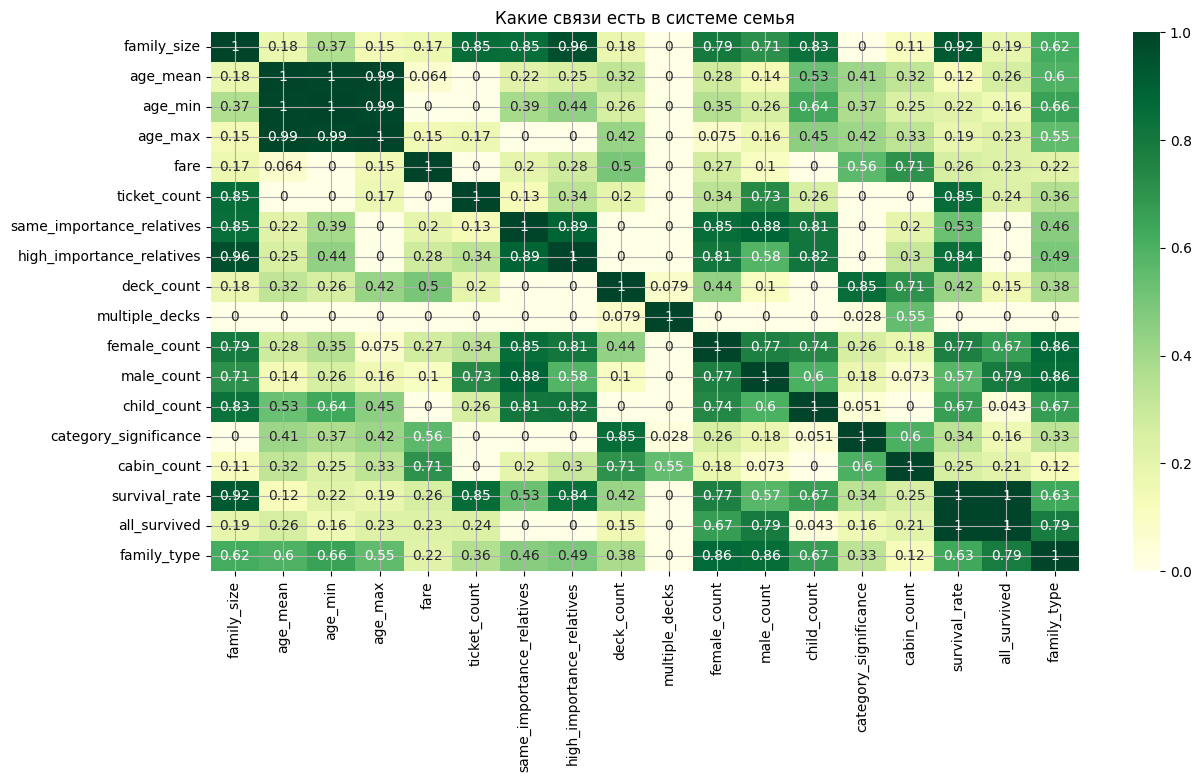

In [47]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    phik_corr_matrix_5,
    annot=True,
    cmap="YlGn",
)

plt.title('Какие связи есть в системе семья')
plt.show()

**Вывод:**

- _`family_size` имеет очень высокую связь с целевым признаком, даже выше чем признак количества пассажиров `ticket_count`. С этой связью нужно быть аккуратнее, потому что при группировке картина складывается таким образом, что большая семья из 5 человек может конкурировать с семьёй из 1ого человека, соответственно это будет создавать смещение `survival_rate` в сторону большой семьи. **Нужно смотреть детальнее.**;_
- _Связь `family_size` со всеми количественными признаками очевидна;_
- Также заметно, что сам признак `family_size` лучше коррелирует, чем признаки пола, связанные с количеством. При моделировании будут конкурировать `family_size`,
`same_importance_relatives`, `high_importance_relatives`;_
- _С возрастными признаками ничего нового замечено не было;_
- _Женщины чаще путешествовали с детьми. Семейная группа на Titanic была не симметричной. Можно подумать над созданием признаков:_
    - _`female_with_children`;_
    - _`male_with_family`;_
    - _`family_with_children`._
**Нужно смотреть детальнее**
- _`deck_count` имеет большую зависимость в `fare`, но `cabin_count` намного значительнее. Также он как-то плохо образован, что заметно по отсутствию зависимости с `multiply_decks`. Щупать эту историю смысла нет;_



_В общем, чего-то принципиально нового открыто не было. Всё проанализировано вдоль и поперёк. Таблица помогла разобраться с признаками семейности. `family_size` очень хороший признак для модели._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>

<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 485px;font-weight: 600;">Что именно внутри <code>family_size</code> работает?</h3></div>


Семья сама по себе повышала шанс выживания или эффект объясняется составом семьи? Кто именно внутри семьи давал преимущество?

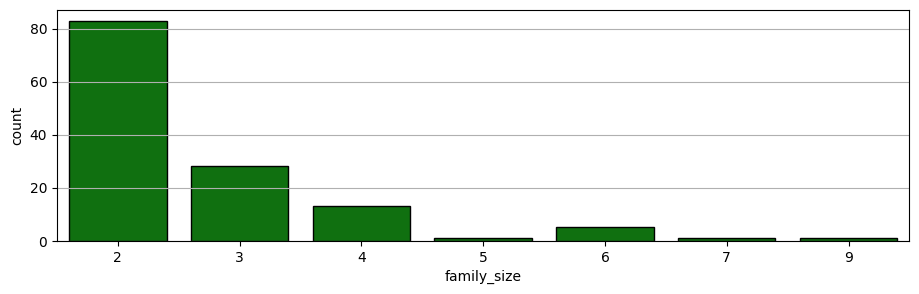

In [48]:
sns.countplot(
    data=family_group[family_group['family_size'] > 1],
    x='family_size'
);

**Вывод:**

_Распределение сильно скошено. Реально исследовать можно только семьи размером 2, 3 и 4. Всего пассажиров 300 из 800 - достаточно значимая группа._

In [49]:
family_group['family_size_group'] = np.where(
    family_group['family_size'] >= 4,
    '4+',
    family_group['family_size'].astype(str)
)

family_group.groupby('family_size_group').agg(
    families=('family_size','count'),
    survival_rate=('survival_rate','mean')
)

,families,survival_rate
family_size_group,,
1,534,0.359551
2,83,0.524096
3,28,0.357143
4+,21,0.351852


**Вывод:**

Преимущество даёт не семья вообще, а именно маленькая семья из двух человек. Наличие одного близкого человека рядом повышало шанс выживания, но большие семейные группы теряли это преимущество

In [50]:
group = (
    family_group.groupby('family_type')['survival_rate'].describe()
    .loc[:,['count', 'mean', '25%', '50%', '75%']]
)

group[group['count'] > 9]

,count,mean,25%,50%,75%
family_type,,,,,
men_children,20.0,0.300000,0.000000,0.0,0.541667
men_women,54.0,0.476852,0.333333,0.5,0.666667
men_women_children,33.0,0.516835,0.000000,0.5,0.750000
only_men,389.0,0.167309,0.000000,0.0,0.000000
only_women,147.0,0.809524,1.000000,1.0,1.000000
women_children,23.0,0.869565,1.000000,1.0,1.000000


**Вывод:**



_Анализ состава семейных групп показывает, что вероятность выживания в первую очередь определяется наличием женщин в группе. Мужские группы имели самую низкую долю выживших (16.7%), тогда как женские группы — самую высокую (81.0%). Наличие детей рядом с мужчинами связано с увеличением доли выживших (до 30.0%), однако этот эффект существенно слабее, чем эффект присутствия женщин (0.48)._

_Добавление детей к смешанным группам (мужчины и женщины) не приводит к заметному росту вероятности выживания, что позволяет предположить, что именно половой состав группы, а не наличие детей, был основным фактором, связанным с выживаемостью._

_`men_women` также может учитывать братьев и сестёр._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>

<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 580px;font-weight: 600;">Какие признаки лучше описывают настоящий <code>age</code></h3></div>


Насколько хорошо `social_role_and_sex` описывает признак `age`

In [51]:
(
    titanic.groupby(['social_role_and_sex'])['age'].describe()
)

,count,mean,std,min,25%,50%,75%,max
social_role_and_sex,,,,,,,,
adult_man,397.0,32.409321,12.698150,11.00,23.000,30.0,39.00,80.0
adult_woman,107.0,35.785046,11.426573,14.00,27.500,35.0,44.00,63.0
other,26.0,42.384617,13.200233,23.00,29.000,44.5,51.75,70.0
young_man,36.0,4.574167,3.619872,0.42,1.000,3.5,8.00,12.0
young_woman,144.0,21.868055,13.036627,0.75,14.375,21.0,30.00,63.0


In [52]:
titanic[titanic['age'].isna()]['social_role_and_sex'].value_counts()

social_role_and_sex
adult_man      119
young_woman     36
adult_woman     17
young_man        4
other            1
Name: count, dtype: int64

**Вывод:**

_Признак `social_role_and_sex` оказался недостаточно детализирован для восстановления возраста. Если группы `young_man` и частично `adult_woman` имеют относительно компактное распределение, то категории `adult_man` и особенно `young_woman` объединяют пассажиров с очень широким диапазоном возрастов._

_Например, в группе `adult_man` возраст варьируется от 11 до 80 лет, поэтому заполнение пропусков медианой неизбежно исказит распределение возраста и нарушит его связь с другими признаками, в частности с `category_significance`._

Попробуем уточнить распределния добавив `category_significance`:

In [53]:
(
    titanic
    .groupby(
        ['category_significance', 'social_role_and_sex']
    )['age']
    .describe()
    .rename_axis(['category', 'role'])
)

count       mean        std    min    25%   50%     75%  \
category role                                                                   
1        adult_man     87.0  41.580460  14.148275  17.00  29.50  40.0  50.500   
         adult_woman   34.0  40.882355  12.643755  17.00  35.00  41.5  50.750   
         other         17.0  43.411766  13.119922  24.00  33.00  45.0  50.000   
         young_man      3.0   5.306667   5.165475   0.92   2.46   4.0   7.500   
         young_woman   45.0  30.000000  12.852308   2.00  21.00  30.0  36.000   
2        adult_man     82.0  32.768291  11.850977  16.00  24.25  31.0  36.375   
         adult_woman   41.0  33.682926  10.318524  14.00  26.00  32.0  41.000   
         other          9.0  40.444443  13.920408  23.00  28.00  42.0  54.000   
         young_man      9.0   2.258889   2.342634   0.67   0.83   1.0   3.000   
         young_woman   32.0  22.390625  13.374708   2.00  11.75  24.0  30.625   
3        adult_man    228.0  28.780703  10.479902  11.00  21.00  26.0  34.000   
         adult_woman   32.0  33.062500   9.843739  15.00  27.00  31.0  39.250   
         young_man     24.0   5.350833   3.593608   0.42   2.00   4.0   9.000   
         young_woman   67.0  16.156717   9.785564   0.75   8.50  18.0  22.000   

                       max  
category role               
1        adult_man    80.0  
         adult_woman  62.0  
         other        70.0  
         young_man    11.0  
         young_woman  63.0  
2        adult_man    70.0  
         adult_woman  57.0  
         other        57.0  
         young_man     8.0  
         young_woman  50.0  
3        adult_man    74.0  
         adult_woman  63.0  
         young_man    12.0  
         young_woman  45.0

**Вывод:**

_Добавление category_significance позволило сделать группы social_role_and_sex более однородными: медианный возраст закономерно уменьшается от первой категории значимости к третьей практически для всех социальных групп. Однако получившиеся категории всё ещё имеют слишком большой разброс возраста._

_Например, в группе adult_man диапазон возрастов остаётся от 11–17 до 70–80 лет в зависимости от категории значимости, а группа young_woman одновременно включает маленьких девочек, подростков и взрослых женщин. Следовательно, даже совместное использование social_role_and_sex и category_significance не позволяет сформировать достаточно узкие группы для надёжного восстановления возраста._

_Попробуем теперь уточнить распределения признаками семейности._

In [54]:
(
    titanic.groupby(
        ['category_significance', 'family_type', 'social_role']
    )['age']
    .describe()
    .rename_axis(['category', 'family_type', 'role'])
)

count       mean        std    min     25%  \
category family_type        role                                                
1        men_children       child    1.0   4.000000        NaN   4.00   4.000   
         men_women          adult   33.0  39.272728  11.651912  19.00  33.000   
                            child   10.0  29.900000  13.059267  18.00  23.000   
                            other    5.0  52.200001  10.207840  44.00  48.000   
         men_women_children adult   12.0  31.833334  12.918158  17.00  17.750   
                            child    4.0   6.980000   6.505505   0.92   1.730   
         only_men           adult   61.0  42.844261  14.564095  19.00  31.000   
                            other    7.0  46.142857  10.237652  32.00  39.000   
         only_women         adult   14.0  48.000000  11.107862  18.00  43.500   
                            child   29.0  33.517242  11.214215  18.00  24.000   
                            other    5.0  30.799999  10.894953  24.00  24.000   
         women_children     adult    1.0  44.000000        NaN  44.00  44.000   
                            child    4.0  15.750000   0.500000  15.00  15.750   
2        men_children       adult    5.0  23.500000   9.591663  16.00  16.000   
                            child    4.0   3.500000   3.109126   1.00   1.750   
         men_women          adult   20.0  35.299999  12.096541  19.00  27.750   
                            child    3.0  32.166668   8.005207  24.00  28.250   
         men_women_children adult   14.0  30.464285   9.287014  14.00  24.000   
                            child   11.0   3.575455   2.649605   0.67   0.915   
                            other    2.0  41.000000  18.384777  28.00  34.500   
         only_men           adult   61.0  32.573769  11.936581  18.00  24.000   
                            other    6.0  42.333332  14.389812  23.00  30.750   
         only_women         adult   21.0  36.047619   9.805490  23.00  29.000   
                            child   18.0  29.666666   9.542475  18.00  24.000   
                            other    1.0  28.000000        NaN  28.00  28.000   
         women_children     adult    2.0  37.000000   5.656854  33.00  35.000   
                            child    5.0  10.600000   7.162402   2.00   4.000   
3        men_children       adult   17.0  19.176470   8.156556  11.00  16.000   
                            child    4.0   3.355000   3.922257   0.42   0.855   
         men_women          adult   21.0  29.857143   7.418125  18.00  25.000   
                            child    6.0  24.166666   5.036533  20.00  20.250   
         men_women_children adult   30.0  29.966667  10.080651  14.00  21.750   
                            child   38.0   7.184210   4.914706   1.00   3.000   
         only_men           adult  181.0  29.734806  10.408135  18.00  22.000   
                            child    0.0        NaN        NaN    NaN     NaN   
         only_women         adult    8.0  38.625000  13.574530  18.00  30.500   
                            child   27.0  24.018518   6.190069  18.00  20.000   
         women_children     adult    3.0  25.666666   2.886751  24.00  24.000   
                            child   16.0   8.187500   6.174207   0.75   3.500   

                                    50%     75%   max  
category family_type        role                       
1        men_children       child   4.0   4.000   4.0  
         men_women          adult  38.0  48.000  64.0  
                            child  26.5  32.500  63.0  
                            other  49.0  50.000  70.0  
         men_women_children adult  33.5  41.250  49.0  
                            child   6.5  11.750  14.0  
         only_men           adult  42.0  54.000  80.0  
                            other  45.0  54.000  60.0  
         only_women         adult  51.5  53.750  62.0  
                            child  31.0  39.000  58.0  
                            other  24.0  

**Вывод:**

*Данная таблица выглядит сильно лучше остальных. Попробуем просчитать какая формула будет лучше.*

*Расчитаем метрику ошибок MAE для каждой формулы:*

In [55]:
groups = {
    'category_family_role': [
        'category_significance',
        'family_type',
        'social_role'
    ],
    'category_role': [
        'category_significance',
        'social_role'
    ],
    'category_family': [
        'category_significance',
        'family_type'
    ],
    'role_sex_relatives': [
        'social_role_and_sex',
        'high_importance_relatives'
    ]
}


results = {}

for group_name, group in groups.items():

    age_prediction = (
        titanic
        .groupby(group)['age']
        .transform('median')
    )

    error = (
        titanic['age'] - age_prediction
    ).abs()

    results[group_name] = error.describe()


results_df = pd.DataFrame(results)

results_df

,category_family_role,category_role,category_family,role_sex_relatives
count,710.000000,710.000000,710.000000,710.000000
mean,7.549761,9.222296,9.223704,8.861732
std,7.255794,7.336195,7.926272,8.056828
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,3.000000,3.000000
50%,6.000000,8.000000,7.000000,7.000000
75%,10.000000,12.000000,13.000000,12.000000
max,47.000000,46.000000,47.000000,51.000000


**Вывод:**

_Исследование стратегий восстановления возраста показало, что наиболее информативной группировкой является комбинация category_significance, family_type и social_role. Данная комбинация учитывает одновременно социальное положение пассажира, семейный состав группы и жизненный этап. Заполнение пропусков медианным возрастом внутри этих групп показало среднюю абсолютную ошибку 7.55 лет, что лучше альтернативных вариантов группировки. В некоторых случаях улучшение почти на 1.7 года._

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Промежуточный вывод


<div style="
color: green;
padding: 20px;
border: 2px dotted green;
">

_Были изучены:_

* _Исходные признаки Titanic;_
* _Признаки, которые были добавлены после поверхностного знакомства с данными;_
* _Признаки, которые показали высокую информативность после иерархического анализа зависимостей._

_Основная цель заключалась в поиске признаков, связанных с целевой переменной `survived`. Проведённый анализ показал, что большинство наблюдаемых зависимостей нельзя интерпретировать напрямую. Итоговая формула `survived` объясняется существованием небольшого числа скрытых факторов, которые также объясняют большую часть обнаруженных корреляций в принципе._

**Лучше всего в нашей ситуации работают признаки с таким смыслом:**

* _**Семейная структура.** Признаки семейной структуры содержат полезную информацию, однако значительная её часть пересекается с признаками `sex` и `age`: максимальный эффект у семей из двух человек `family_group`,но основным фактором является наличие женщин (группы только мужчин имеют минимальную выживаемость, смешанные группы занимают промежуточное положение, а группы с женщинами — наиболее высокое) Поэтому при построении модели необходимо оценить, какие признаки семейной структуры (`family_size`, `family_size_group`, `is_alone`, `high_importance_relatives` и др.) действительно повышают качество модели, а какие лишь дублируют уже существующие зависимости.
* _**Cоциальный класс.** Наиболее информативным оказался `category_significance`, который включает в себя информацию о классе обслуживания и положении пассажира на корабле (всё связанное с `cabin`, `embarket`). Дополнительные признаки, связанные с каютами и палубами, в основном отражают тот же фактор._
* **Демографические признаки.** `sex` и `age` остаются базовыми признаками, которые необходимо учитывать при построении модели.
* _**Размер группы по билету.** `ticket_group_size` содержит информацию о совместном путешествии пассажиров и может использоваться как отдельный признак, так как описывает социальные связи, которые не всегда совпадают с семейными._

Остальные признаки требуют проверки на избыточность и вклад в качество модели.

</div>

<div style="
color: green;
padding: 20px;
border: 2px dotted green;
">

_**Второстепенная цель - заполнение пропусков.**_

_Заполнение `deck` и `cabin` через любые существующие корреляции (`sex`, `age`, `fare`, `category_significance`, `embarket`, `ticket_prefix`) оказалось невозможным. Более того, по мере анализа всех существующих корреляций, каждый раз выяснялось, что их существование было следствием аномалии (особенностью заполнения данных): информация о каютах сохранилась преимущественно для пассажиров первого класса._

_Стало понятно, что высокая связь с целевым признаком достигалась за счёт дублирования информации `category_significance`, так как данный признак полностью включал в себя информацию признака `deck`. Соответственно в Titanic все наиболее значимые для выживания привилегии связанные с кабинами и палубами получали пассажиры первого класса._

_Исследование стоимости билетов `fare` показало, что `cabin_count` количество кабин помогало сильнее восстановить различия внутри отдельных групп. К сожалению, восстановить данный признак тоже просто не оказалось возможным;_

_Исследование признака age показало, что отдельные признаки (`social_role`, `social_role_and_sex`, `category_significance`) недостаточно хорошо описывают возраст пассажиров. Наиболее точное восстановление удалось получить при совместном использовании признаков `category_significance`, `family_type` и `social_role`, которые одновременно учитывают социальное положение пассажира, семейную структуру и жизненный этап. Заполнение пропусков медианным возрастом внутри таких групп показало наименьшую среднюю абсолютную ошибку (MAE ≈ 7.55 года) по сравнению с другими рассмотренными стратегиями группировки. Данный подход выбран в качестве основной стратегии заполнения пропусков возраста._

</div>


<div style="
color: green;
padding: 20px;
border: 2px dotted green;
">

_**Второстепенная цель - уменьшить шум.**_

_В ходе анализа было установлено, что ряд признаков описывает одни и те же скрытые свойства пассажиров с разных сторон. Такие признаки потенциально могут конкурировать между собой при обучении модели и не всегда дают дополнительную информацию при совместном использовании._

_Признаки `same_importance_relatives`, `high_importance_relatives`, `ticket_group_size`, `is_alone` и `family_size` характеризуют наличие и размер группы, в которой путешествовал пассажир. При этом было отмечено всего 44 случая путешествия с людьми, чьи связи с группой оставались неизвестными. В большинстве таких случаев неизвестные пассажиры лишь дополняли семейную группу одним-двумя участниками._

_Признаки `female_count`, `male_count`, `child_count` и `family_type` описывают состав семейной группы. При этом `family_type` является обобщённым представлением состава группы и потенциально может дублировать информацию отдельных счётчиков._

_Признаки `age`, `social_role` и `social_role_and_sex` описывают жизненный этап пассажира с разной степенью детализации. Исследование восстановления возраста также показало, что семейная структура частично связана с этим же фактором, поэтому `family_type` может конкурировать с признаками жизненного этапа._

_Признаки `fare`, `category_significance`, `deck`, `cabin_assignment` и `ticket_prefix` частично описывают социальное положение и уровень обслуживания пассажира. Было установлено, что `category_significance` включает информацию о `deck`, а большинство значений `ticket_prefix` также практически полностью привязано к определённым категориям обслуживания. Поэтому их самостоятельная информативность требует дополнительной проверки._

_Анализ `embarked` показал, что его обнаруженные зависимости преимущественно объясняются различным распределением категорий обслуживания между портами посадки. После учёта социального класса самостоятельная информативность порта существенно снижается. Принято решение не использовать данный признак как основной кандидат для модели._

_Необходимо провести анализ важности признаков._

</div>

<div style="
color: green;
padding: 20px;
border: 2px dotted green;
">

_**Второстепенная цель - улучшение качества признаков и создание новых.**_

_В ходе анализа проводилось агрегирование пассажиров по ticket_number и surname, что позволило получить признаки, описывающие не отдельного пассажира, а структуру группы, в которой он путешествовал._

_Группировка по `ticket_number` показала, что количество пассажиров (`passenger_count`) связано с распределением `fare`, `ticket_prefix`, `deck`, `category_significance` и `embarked`. Один билет часто объединял пассажиров с общими характеристиками обслуживания и размещения. При этом были обнаружены случаи, когда один билет объединял несколько семей: дополнительные пассажиры в таких группах чаще являлись попутчиками, а не родственниками. Это позволило рассматривать `ticket_group_size` не только как размер группы, но и как отдельный показатель совместного путешествия._

_Группировка по surname позволила выделить семейные группы и создать `family_size`, `family_type`, `female_count`, `male_count` и `child_count`. Исследование показало, что одного размера семьи недостаточно для описания семейного фактора: группы одинакового размера могли иметь существенно различный состав. Поэтому состав группы рассматривается как отдельная характеристика, а `family_size` и `family_type` — как основные кандидаты для дальнейшей проверки в модели._

Анализ `deck`, `cabin` и `category_significance` показал, что часть наблюдаемых закономерностей нельзя напрямую интерпретировать как влияние расположения каюты. Заполнение `deck` сохранилось преимущественно для пассажиров первой категории, поэтому необычные зависимости отдельных палуб с полом, возрастом и другими признаками могут отражать состав размеченной выборки, а не свойства самой палубы._

_Например, наблюдение о преобладании мужчин на отдельных палубах не позволяет делать общий вывод о связи пола с расположением на корабле. При этом `category_significance` оказался более устойчивым способом представить информацию о социальном положении пассажира, поскольку он сохраняется для значительно большей части наблюдений.

_Аналогичный эффект был обнаружен для `embarked`. Различия между портами в основном объяснялись различным распределением категорий обслуживания: в Q преобладали пассажиры третьей категории, в C была значительно выше доля первой категории, а S имел наиболее смешанный состав. После учёта категории обслуживания самостоятельная связь порта с выживаемостью существенно снижалась. Поэтому создание новых признаков на основе `embarked` не имеет очевидного преимущества._

_Исследование возраста показало, что существующие признаки позволяют уточнить его представление без создания большого количества дополнительных категорий. Наиболее точное восстановление пропущенного `age` получено при совместном использовании `category_significance`, `family_type` и `social_role` (MAE ≈ 7.55 года). Это показало, что социальное положение, семейная структура и жизненный этап совместно дают более точное описание возраста, чем отдельные признаки._

_Таким образом, feature engineering в данном исследовании позволил перейти от отдельных характеристик пассажира к нескольким скрытым факторам: семейной структуре, структуре группы по билету, социальному положению и жизненному этапу._

</div>